# Retail Chain Sales Intelligence
### Exploratory Analytics · LangChain Agent · GPT-4o · Python

Retail data is dense. 45 stores, 81 departments, 3 years of weekly sales enriched with markdown spend, CPI, unemployment, and store metadata. Enough to answer dozens of analytical questions, each of which normally means writing more aggregation code, more statistical boilerplate, more interpretation glue.

This notebook takes a different approach. Python handles data preparation, statistical tests, machine learning, and visualisation. A **LangChain pandas agent backed by GPT-4o** handles interpretation and exploration: receiving verified results as context, translating them into business-language findings, synthesising patterns across sections simultaneously, and answering ad hoc questions against the full 421K-row dataset in plain English.

The division is deliberate. Statistical tests run in scipy, clustering runs in scikit-learn, and for every section that involves formal analysis the agent interprets pre-computed results rather than computing its own. In the exploratory and Q&A sections (Sections 4 and 13), the agent also writes and executes its own code against the live DataFrame, which is its intended use case: answering open-ended analytical questions without manual boilerplate. This keeps every formal number reproducible and auditable, while the agent contributes what a language model actually does well: connecting findings, explaining implications, and producing analysis that reads like it was written by someone who understands the business, not just the data.

**Dataset:** [Walmart Retail Dataset](https://www.kaggle.com/datasets/manjeetsingh/retaildataset) · 421,570 records · 2010-2012

| Layer | Tools |
|---|---|
| LLM Agent | LangChain · langchain_experimental · OpenAI GPT-4o |
| Statistical tests | scipy · statsmodels |
| Machine learning | scikit-learn · K-Means · PCA |
| Data & Visualisation | pandas · numpy · matplotlib · seaborn |

## Table of Contents

1. [Setup](#setup)
2. [Data](#data)
   - 2.1 [Outlier Investigation](#outlier-investigation)
3. [The LLM Agent](#llm-agent)
4. [Exploratory Analysis](#eda)
5. [Seasonality & Sales Patterns](#seasonality)
   - 5.1 [Trend-Seasonality Decomposition](#stl)
6. [Store Performance](#store-performance)
7. [Promotional Markdown Effectiveness](#markdowns)
   - 7.1 [Causal Inference Caveat](#endogeneity)
8. [Macroeconomic Context](#macro)
   - 8.1 [Multicollinearity Check](#multicollinearity)
9. [Store Segmentation](#segmentation)
10. [Hypothesis Testing](#hypothesis-testing)
11. [Department Analysis](#departments)
12. [Synthesis](#synthesis)
13. [Open-Ended Q&A](#qa)
14. [Executive Summary](#executive-summary)
15. [Limitations & Caveats](#limitations)
16. [Reflections](#agent-reflection)


## <a id="setup"></a>1. Setup

Install pinned library versions and configure imports, plotting style, and the API key.


In [1]:
import os

# Detect environment: Google Colab or local
try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/retail-sales-intelligence')
    print("Running on Google Colab")
except ImportError:
    # Local execution: assumes data/ is in the same directory as the notebook
    print("Running locally")

os.makedirs('plots', exist_ok=True)

print("Working directory:", os.getcwd())
print("Files found:", os.listdir('.'))

Mounted at /content/drive
Running on Google Colab
Working directory: /content/drive/MyDrive/retail-sales-intelligence
Files found: ['data', 'retail_sales_analysis.ipynb', 'plots']


In [2]:
!pip install openai==1.72.0 langchain==0.3.23 langchain_openai==0.3.13 \
            langchain_experimental==0.3.4 langchain_community==0.3.21 --quiet 2>/dev/null


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.9/643.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 14.3 MB/s eta 0:00:00


In [3]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent
from langchain.agents.agent_types import AgentType

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2C3E50', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
sns.set_palette(PALETTE)


In [4]:
import os

# Load API key: Colab Secrets if available, otherwise environment variable
try:
    from google.colab import userdata
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
except ImportError:
    # Local: set your key as an environment variable before running
    # Linux/Mac: export OPENAI_API_KEY=your_key
    # Windows:   set OPENAI_API_KEY=your_key
    pass

assert os.environ.get('OPENAI_API_KEY'), "OPENAI_API_KEY not found. Set it as an environment variable."
print("API key loaded.")

API key loaded.


## <a id="data"></a>2. Data

The raw data lives across three separate tables that need to be joined before any analysis is possible.

- `sales data-set.csv`: the core table, **Store x Dept x Week x Sales** (421,570 rows)
- `Features data set.csv`: weekly store context including markdowns, CPI, unemployment, fuel price, and temperature
- `stores data-set.csv`: store metadata with format type (A/B/C) and physical size in sq ft

Merging on `Store + Date` produces a single enriched DataFrame. Missing markdown values are filled with 0 (no promotion active that week), and CPI/Unemployment are forward-filled within each store since they are recorded less frequently than weekly.


In [5]:
sales    = pd.read_csv('data/sales data-set.csv')
features = pd.read_csv('data/Features data set.csv')
stores   = pd.read_csv('data/stores data-set.csv')

for df_ in [sales, features]:
    df_['Date'] = pd.to_datetime(df_['Date'], dayfirst=True)

# Merge everything into one working DataFrame
df = (sales
      .merge(features.drop(columns=['IsHoliday']), on=['Store','Date'], how='left')
      .merge(stores, on='Store', how='left'))

# Feature engineering
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Week']    = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

# Markdowns: treat NA as zero (no promotion running), clip negatives
md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[md_cols] = df[md_cols].fillna(0).clip(lower=0)
df['MarkDown_Total'] = df[md_cols].sum(axis=1)

# CPI / Unemployment: forward-fill within each store (surveyed less frequently)
for col in ['CPI','Unemployment']:
    df[col] = df.groupby('Store')[col].transform(lambda x: x.ffill().bfill())

df['IsHoliday'] = df['IsHoliday'].astype(int)

print(f"Rows: {len(df):,}  |  Stores: {df['Store'].nunique()}  |  Departments: {df['Dept'].nunique()}")
print(f"Period: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()


Rows: 421,570  |  Stores: 45  |  Departments: 81
Period: 2010-02-05 → 2012-10-26


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,MarkDown_Total
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0


In [6]:
# Quick data quality check
print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nNegative Weekly_Sales rows: {(df['Weekly_Sales'] < 0).sum():,} "
      f"(returns/corrections: kept in for accurate totals)")


Missing values after cleaning:
Series([], dtype: int64)

Negative Weekly_Sales rows: 1,285 (returns/corrections: kept in for accurate totals)


### <a id="outlier-investigation"></a>2.1 Outlier Investigation

The dataset contains **negative `Weekly_Sales` values**: accounting corrections and product returns, retained for accurate revenue totals. Before moving on, it is worth checking whether these are randomly distributed or concentrated in specific stores, departments, or time periods.

Random corrections have no analytical consequence. Systematic concentrations, for example negative entries clustering heavily in a few stores or consistently after holiday months, would distort section-level comparisons and are worth flagging before they silently bias the analysis.


In [7]:
neg = df[df['Weekly_Sales'] < 0].copy()
print(f"Negative sales rows: {len(neg):,} ({len(neg)/len(df)*100:.2f}% of all records)")
print(f"Total value of negative entries: ${neg['Weekly_Sales'].sum():,.0f}\n")
print("By store type:")
print(neg.groupby('Type').agg(count=('Weekly_Sales','count'),
                               total=('Weekly_Sales','sum')).assign(
    share_pct=lambda x: x['count']/len(neg)*100).round(2).to_string())
print("\nTop 10 departments with most negative entries:")
print(neg.groupby('Dept').agg(count=('Weekly_Sales','count'),
                               min_val=('Weekly_Sales','min')).sort_values('count',ascending=False).head(10).to_string())
print("\nNegative entries by month:")
print(neg.groupby('Month')['Weekly_Sales'].count().to_dict())


Negative sales rows: 1,285 (0.30% of all records)
Total value of negative entries: $-88,162

By store type:
      count     total  share_pct
Type                            
A       485 -42755.78      37.74
B       676 -40911.52      52.61
C       124  -4494.26       9.65

Top 10 departments with most negative entries:
      count  min_val
Dept                
47      254 -3924.00
18      180  -175.54
54      146  -465.08
19       87   -69.56
94       77  -173.84
80       68  -590.04
49       67  -326.61
59       44   -55.46
72       34  -379.00
78       33   -24.00

Negative entries by month:
{1: 85, 2: 79, 3: 113, 4: 113, 5: 150, 6: 158, 7: 107, 8: 110, 9: 124, 10: 84, 11: 57, 12: 105}


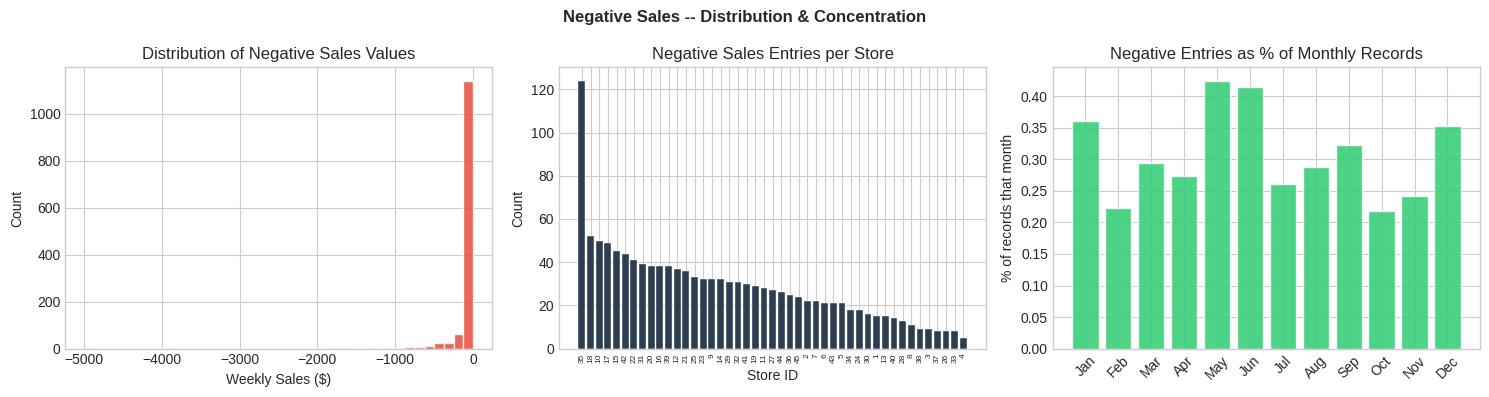

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Negative Sales -- Distribution & Concentration', fontsize=12, fontweight='bold')
ax = axes[0]
ax.hist(neg['Weekly_Sales'], bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
ax.set_title('Distribution of Negative Sales Values')
ax.set_xlabel('Weekly Sales ($)')
ax.set_ylabel('Count')

ax = axes[1]
neg_per_store = neg.groupby('Store')['Weekly_Sales'].count().sort_values(ascending=False)
ax.bar(neg_per_store.index.astype(str), neg_per_store.values,
       color=PALETTE[0], edgecolor='white', linewidth=0.3)
ax.set_title('Negative Sales Entries per Store')
ax.set_xlabel('Store ID')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90, labelsize=6)

ax = axes[2]
neg_monthly = neg.groupby('Month')['Weekly_Sales'].count()
all_monthly  = df.groupby('Month')['Weekly_Sales'].count()
pct = (neg_monthly / all_monthly * 100).fillna(0)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar([month_labels[m-1] for m in pct.index], pct.values,
       color=PALETTE[3], edgecolor='white', alpha=0.85)
ax.set_title('Negative Entries as % of Monthly Records')
ax.set_ylabel('% of records that month')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/outliers.png', dpi=150, bbox_inches='tight')
plt.show()


## <a id="llm-agent"></a>3. The LLM Agent

A LangChain pandas agent backed by **GPT-4o** acts as an analytical layer embedded directly in the notebook. It receives a natural-language question, writes and executes the corresponding Python code against the live 421K-row DataFrame, and returns interpreted results, all in a single `agent.invoke()` call.

The agent is initialised with full domain context: column definitions, the store type hierarchy, the four holiday events, key data quality caveats, and the date range. This grounding is what makes the responses business-specific rather than generic.

**What runs where, and why:**

- **Python** owns all statistical tests, ML pipelines, and visualisations. These must be reproducible independently of any LLM.
- **The agent** has two modes of operation. In the **exploratory and Q&A sections** (Sections 4 and 13), it writes and executes its own code against the live DataFrame, which is its intended use case for open-ended questions. In all **formal analysis sections**, it receives pre-computed results as structured context and focuses purely on interpretation, translating numbers into business-language findings.


In [9]:
llm = ChatOpenAI(
    model='gpt-4o',
    temperature=0,
    max_tokens=6000,
)

SYSTEM_CONTEXT = """IMPORTANT: At the start of every code block you write, always include these imports if you use them:\nimport pandas as pd; import numpy as np; from scipy import stats; from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal, pearsonr\n\nYou are an experienced retail data analyst working with weekly sales data\nfrom a 45-store retail chain (2010-2012). The DataFrame `df` contains 421,570 rows with these key columns:\n\n- Store (1-45), Dept (1-99), Date, Weekly_Sales, IsHoliday (0/1)\n- Type (store category: A=large, B=medium, C=small), Size (sq ft)\n- MarkDown1-5 (promotional discount spend, 0 = no promotion), MarkDown_Total\n- Temperature, Fuel_Price, CPI, Unemployment (economic context per store/week)\n- Year, Month, Week, Quarter (derived from Date)\n\nThe four major holiday weeks are: Super Bowl (Feb), Labor Day (Sep), Thanksgiving (Nov), Christmas (Dec).\nStores of Type A are the largest and highest-volume; Type C are small-format stores.\nWhen computing correlations or running tests involving IsHoliday or Type, treat them appropriately.\nAlways report statistics with business context, not just numbers.
When reporting percentage uplifts, flag cases where the baseline is near zero, as extreme
percentages on tiny bases are mathematical artefacts rather than actionable signals.\n"""

agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    verbose=True,    # Set to False for clean presentation
    agent_type=AgentType.OPENAI_FUNCTIONS,
    prefix=SYSTEM_CONTEXT,
    allow_dangerous_code=True,
    max_iterations=12,
)

print("Agent ready.")


Agent ready.


## <a id="eda"></a>4. Exploratory Analysis

Before asking targeted questions, we need to understand the distributional shape of the data. Whether weekly sales are symmetric or heavily skewed, whether a few outliers dominate the totals, and how much variation sits between store types versus within them. These properties determine which summary statistics are trustworthy in every section that follows.

We use the agent here for a reason: this kind of open-ended overview benefits from natural language. A single prompt replaces a sequence of independent aggregations and produces an interpreted narrative, not just a table of numbers.

**Reading the agent output.** The green blocks below each agent call show the code the agent wrote and executed autonomously.


In [10]:
# Overview statistics: let the agent summarise what it sees
response = agent.invoke("""\nGive me a concise but complete overview of this dataset. Include:\n- Total revenue across all stores and the full period\n- Average and median weekly sales per store-department combination\n- How sales break down by store type (A, B, C): both total and average\n- The percentage of weeks that are flagged as holiday weeks, and the average sales uplift those weeks carry\n- Any immediate data quality observations worth flagging\n\nKeep it factual and well-structured. Use numbers throughout.\n""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "# Calculate total revenue across all stores and the full period\ntotal_revenue = df['Weekly_Sales'].sum()\ntotal_revenue"}`


6737218987.11
Invoking: `python_repl_ast` with `{'query': "# Calculate average and median weekly sales per store-department combination\navg_weekly_sales = df.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().mean()\nmedian_weekly_sales = df.groupby(['Store', 'Dept'])['Weekly_Sales'].median().median()\n(avg_weekly_sales, median_weekly_sales)"}`


(np.float64(14175.598347939265), 5486.03)
Invoking: `python_repl_ast` with `{'query': "# Calculate total and average sales by store type\ntotal_sales_by_type = df.groupby('Type')['Weekly_Sales'].sum()\navg_sales_by_type = df.groupby('Type')['Weekly_Sales'].mean()\n(total_sales_by_type, avg_sales_by_type)"}`


(Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64, Type
A    20099.568043
B    1223

### Dataset Overview

1. **Total Revenue**:
   - The total revenue across all stores and the full period is approximately $6.74 billion.

2. **Weekly Sales per Store-Department Combination**:
   - The average weekly sales per store-department combination is approximately $14,176.
   - The median weekly sales per store-department combination is approximately $5,486.

3. **Sales Breakdown by Store Type**:
   - **Type A (Large Stores)**:
     - Total Sales: $4.33 billion
     - Average Weekly Sales: $20,100
   - **Type B (Medium Stores)**:
     - Total Sales: $2.00 billion
     - Average Weekly Sales: $12,237
   - **Type C (Small Stores)**:
     - Total Sales: $405 million
     - Average Weekly Sales: $9,520

4. **Holiday Weeks**:
   - Approximately 7.04% of the weeks are flagged as holiday weeks.
   - The average sales uplift during holiday weeks is about 7.13%.

5. **Data Quality Observations**:
   - There are no missing values in the dataset.
   - There are 1,285 instances of negative sales values, which may require further investigation to ensure data accuracy.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Interpreting the agent's overview: why the mean/median gap matters**

The mean/median gap, **\$14,176 average vs \$5,486 median**, is the number that should frame how you read every section that follows. A 2.6x difference confirms extreme right-skew: a small number of high-revenue store-department combinations are pulling the average up significantly. When the agent reports "Type A avg = $20,099", that figure is lifted by a handful of exceptional combinations. The median tells the more representative story.

This kind of distributional observation is exactly the kind of finding that gets skipped when analysis jumps directly to specific questions. The agent surfaced it unprompted, which is one of the advantages of an open-ended first pass before targeted analysis.


</div>


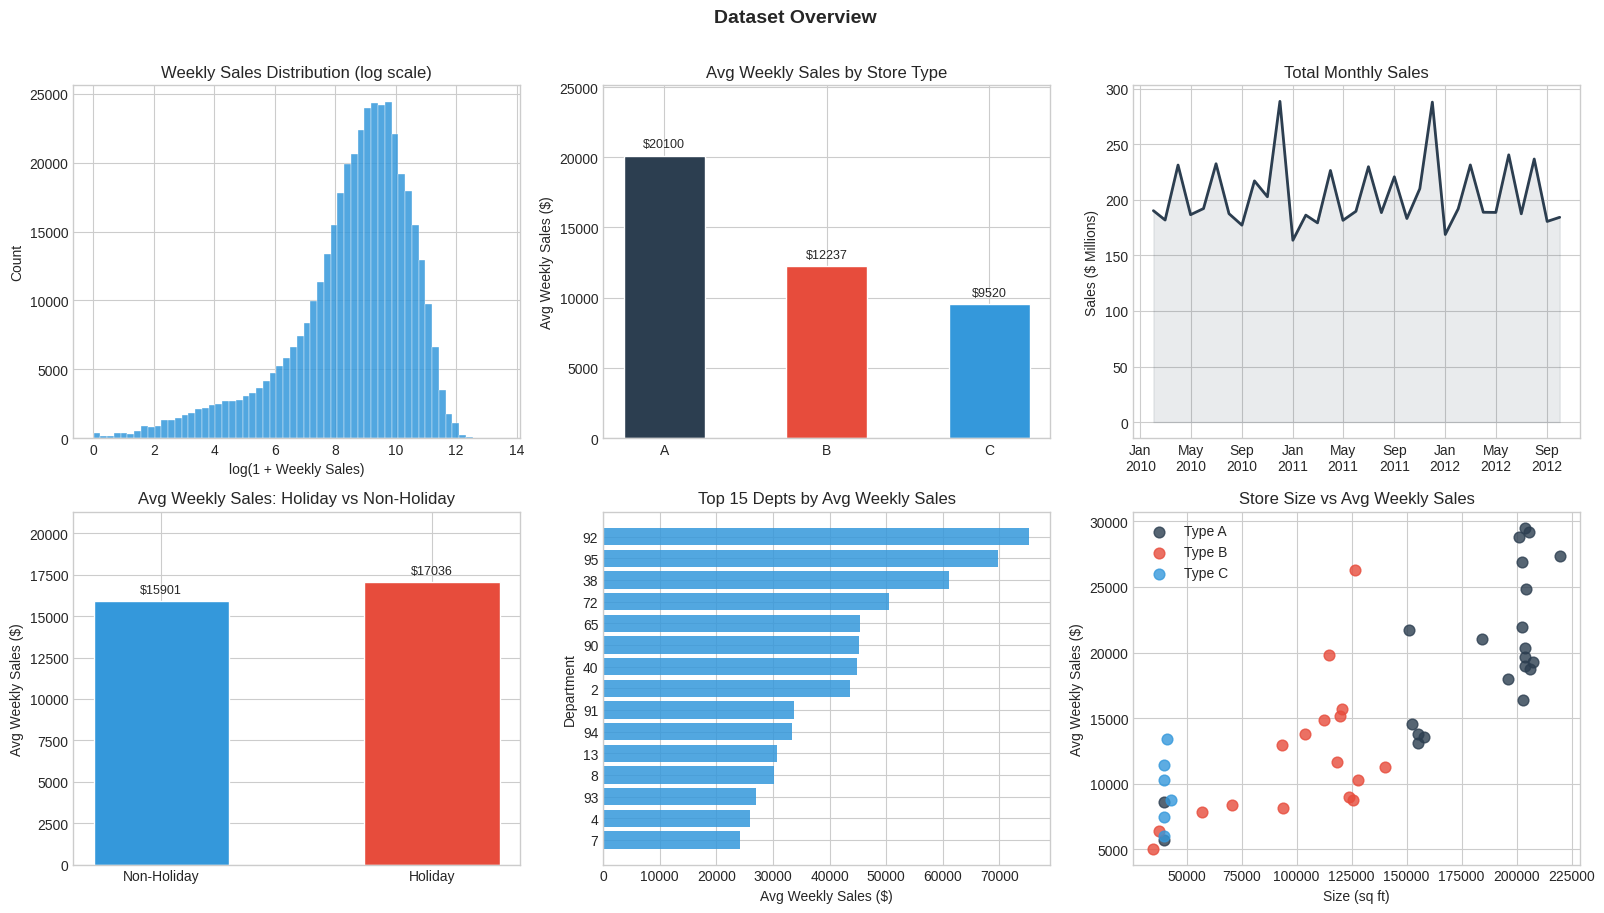

In [11]:
# Visual overview
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.01)

# 1. Sales distribution
ax = axes[0,0]
ax.hist(np.log1p(df[df['Weekly_Sales']>0]['Weekly_Sales']), bins=60,
        color=PALETTE[2], edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_title('Weekly Sales Distribution (log scale)')
ax.set_xlabel('log(1 + Weekly Sales)')
ax.set_ylabel('Count')

# 2. Avg sales by store type
ax = axes[0,1]
type_avg = df.groupby('Type')['Weekly_Sales'].mean()
bars = ax.bar(type_avg.index, type_avg.values, color=PALETTE[:3], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)
ax.set_title('Avg Weekly Sales by Store Type')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.set_ylim(0, type_avg.max() * 1.25)

# 3. Total sales over time
ax = axes[0,2]
monthly = df.groupby(df['Date'].dt.to_period('M'))['Weekly_Sales'].sum()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values/1e6, color=PALETTE[0], linewidth=2)
ax.fill_between(monthly.index, monthly.values/1e6, alpha=0.1, color=PALETTE[0])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.set_title('Total Monthly Sales')
ax.set_ylabel('Sales ($ Millions)')

# 4. Holiday vs non-holiday
ax = axes[1,0]
hol = df.groupby('IsHoliday')['Weekly_Sales'].mean()
bars = ax.bar(['Non-Holiday','Holiday'], hol.values, color=[PALETTE[2],PALETTE[1]],
              edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)
ax.set_title('Avg Weekly Sales: Holiday vs Non-Holiday')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.set_ylim(0, hol.max() * 1.25)

# 5. Top 15 departments
ax = axes[1,1]
top_depts = df.groupby('Dept')['Weekly_Sales'].mean().nlargest(15)
ax.barh(top_depts.index.astype(str)[::-1], top_depts.values[::-1], color=PALETTE[2], alpha=0.85)
ax.set_title('Top 15 Depts by Avg Weekly Sales')
ax.set_xlabel('Avg Weekly Sales ($)')
ax.set_ylabel('Department')

# 6. Store size vs avg sales
ax = axes[1,2]
sp = df.groupby(['Store','Type','Size'])['Weekly_Sales'].mean().reset_index()
for t, c in zip(['A','B','C'], PALETTE[:3]):
    s = sp[sp['Type']==t]
    ax.scatter(s['Size'], s['Weekly_Sales'], color=c, label=f'Type {t}', s=60, alpha=0.8)
ax.set_title('Store Size vs Avg Weekly Sales')
ax.set_xlabel('Size (sq ft)')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## <a id="seasonality"></a>5. Seasonality & Sales Patterns

The dataset flags four holiday events (Super Bowl, Labor Day, Thanksgiving, Christmas), but planning resources evenly across all four would be a mistake. Understanding *which* events actually drive sales, and by how much, is one of the most actionable outputs of this analysis.

Python pre-computes the weekly totals, holiday uplifts by event, and year-over-year figures, then passes them to the agent with two explicit caveats embedded in the context: the dataset is truncated in October 2012, and the December holiday flag marks the week of Christmas itself, not the peak shopping week.


In [12]:
# Pre-compute all seasonality metrics in Python
# (avoids agent losing pd/numpy in multi-step execution)

# 1. Top/bottom 5 weeks by total sales
weekly_by_week = df.groupby('Week')['Weekly_Sales'].sum().reset_index()
top5_weeks    = weekly_by_week.nlargest(5, 'Weekly_Sales')[['Week','Weekly_Sales']].round(0)
bottom5_weeks = weekly_by_week.nsmallest(5, 'Weekly_Sales')[['Week','Weekly_Sales']].round(0)

# 2. Holiday uplift by month (separates the 4 holiday events)
# Holiday months: Feb (Super Bowl), Sep (Labor Day), Nov (Thanksgiving), Dec (Christmas)
holiday_months = df[df['IsHoliday']==1].groupby('Month')['Weekly_Sales'].mean()
nonhol_months  = df[df['IsHoliday']==0].groupby('Month')['Weekly_Sales'].mean()
holiday_comparison = pd.DataFrame({
    'holiday_avg':    holiday_months,
    'nonholiday_avg': nonhol_months
}).dropna()
holiday_comparison['uplift_pct'] = (
    (holiday_comparison['holiday_avg'] / holiday_comparison['nonholiday_avg'] - 1) * 100
).round(2)
holiday_comparison = holiday_comparison[holiday_comparison.index.isin([2, 9, 11, 12])]
holiday_comparison.index = holiday_comparison.index.map(
    {2:'Feb (Super Bowl)', 9:'Sep (Labor Day)', 11:'Nov (Thanksgiving)', 12:'Dec (Christmas)'}
)

# 3. Annual sales + YoY growth
annual_sales = df.groupby('Year')['Weekly_Sales'].sum()
yoy = {}
for yr in [2011, 2012]:
    prev = annual_sales.get(yr-1)
    curr = annual_sales.get(yr)
    if prev is not None and curr is not None and prev != 0:
        yoy[yr] = round((curr/prev - 1)*100, 2)

# 4. Monthly avg by year (consistency check)
monthly_by_year = df.groupby(['Year','Month'])['Weekly_Sales'].mean().unstack('Year').round(0)

print("Top 5 weeks by total sales:")
print(top5_weeks.to_string(index=False))
print("\nBottom 5 weeks by total sales:")
print(bottom5_weeks.to_string(index=False))
print("\nHoliday event uplift vs same-month non-holiday weeks:")
print(holiday_comparison[['holiday_avg','nonholiday_avg','uplift_pct']].to_string())
print(f"\nAnnual total sales: {annual_sales.to_dict()}")
print(f"YoY growth: {yoy}")

# ── Data truncation warning ───────────────────────────────────────────────────
print("\n⚠️  DATA TRUNCATION NOTE:")
print("   Dataset ends 2012-10-26. Nov and Dec 2012 (highest months) are MISSING.")
print("   The -18.3% YoY figure is NOT a business decline: it is a data artifact.")
print("   Comparable Jan-Oct period only:")
jan_oct_2010 = df[(df['Year']==2010) & (df['Month']<=10)]['Weekly_Sales'].sum()
jan_oct_2011 = df[(df['Year']==2011) & (df['Month']<=10)]['Weekly_Sales'].sum()
jan_oct_2012 = df[(df['Year']==2012) & (df['Month']<=10)]['Weekly_Sales'].sum()
yoy_comparable = {
    2011: round((jan_oct_2011/jan_oct_2010 - 1)*100, 2),
    2012: round((jan_oct_2012/jan_oct_2011 - 1)*100, 2),
}
print(f"   Jan-Oct 2010: ${jan_oct_2010:,.0f}")
print(f"   Jan-Oct 2011: ${jan_oct_2011:,.0f}  YoY: {yoy_comparable[2011]:+.1f}%")
print(f"   Jan-Oct 2012: ${jan_oct_2012:,.0f}  YoY: {yoy_comparable[2012]:+.1f}%")

# ── Christmas flag timing explanation ─────────────────────────────────────────
print("\n📋  CHRISTMAS UPLIFT NOTE:")
print("   IsHoliday=1 for December marks the week OF Dec 25 (returns + last-minute).")
print("   The actual shopping peak is week 51: the highest-sales week of the year")
print(f"   ($157.9M): which is NOT flagged as a holiday.")
print("   The -29.25% Christmas 'uplift' reflects this flag timing mismatch,")
print("   not a genuine sales drop during the Christmas season.")


Top 5 weeks by total sales:
 Week  Weekly_Sales
   51   157929657.0
   22   147242187.0
    7   147190215.0
   27   147011815.0
   14   146755073.0

Bottom 5 weeks by total sales:
 Week  Weekly_Sales
    4    79434828.0
    2    82696757.0
    3    82735645.0
   52    86474980.0
    1    87731210.0

Holiday event uplift vs same-month non-holiday weeks:
                     holiday_avg  nonholiday_avg  uplift_pct
Month                                                       
Feb (Super Bowl)    16377.996441    15885.457253        3.10
Sep (Labor Day)     15881.693339    14859.674828        6.88
Nov (Thanksgiving)  22220.944538    15894.478108       39.80
Dec (Christmas)     14543.387158    20555.149864      -29.25

Annual total sales: {2010: 2288886120.41, 2011: 2448200007.35, 2012: 2000132859.35}
YoY growth: {2011: np.float64(6.96), 2012: np.float64(-18.3)}

⚠️  DATA TRUNCATION NOTE:
   Dataset ends 2012-10-26. Nov and Dec 2012 (highest months) are MISSING.
   The -18.3% YoY figure is NO

In [13]:
top5_str   = top5_weeks.to_string(index=False)
bot5_str   = bottom5_weeks.to_string(index=False)
hol_str    = holiday_comparison[['holiday_avg','nonholiday_avg','uplift_pct']].to_string()
annual_str = annual_sales.to_string()

response = agent.invoke(f"""
Here are pre-computed seasonality metrics (use these numbers directly):

TOP 5 WEEKS BY TOTAL CHAIN SALES:
{top5_str}

BOTTOM 5 WEEKS BY TOTAL CHAIN SALES:
{bot5_str}

HOLIDAY EVENT UPLIFT VS NON-HOLIDAY WEEKS IN SAME MONTH:
{hol_str}
(Index = holiday event, holiday_avg vs nonholiday_avg, uplift_pct = % difference)

ANNUAL TOTAL SALES:
{annual_str}

YEAR-OVER-YEAR GROWTH: {yoy}

Based on these results:
1. Map the top 5 and bottom 5 weeks to the likely retail calendar events they correspond to.
   What explains the peaks and troughs?
2. Are all four holiday events equally impactful? Which drives the largest uplift and which
   the smallest: and what does that imply for inventory and staffing allocation?
3. Does the business show consistent YoY growth? Is the seasonal pattern stable across
   2010, 2011, and 2012, or does the relative importance of events shift?
4. Key planning implication: given this seasonal structure, when should the chain
   concentrate its inventory pre-build and markdown scheduling?

CRITICAL CONTEXT FOR INTERPRETATION (address these explicitly):
- The 2012 YoY of -18.3% is a DATA ARTIFACT, not a business decline. The dataset
  ends Oct 26 2012: Nov and Dec (highest months) are missing. Use yoy_comparable
  for accurate Jan-Oct comparison instead.
- The Christmas uplift of -29.25% is a FLAG TIMING issue: IsHoliday marks the week
  OF Dec 25 (returns/last-minute), not the peak shopping week. Week 51 is the actual
  Christmas peak (highest week in the dataset) and is NOT flagged. Explain this clearly.
""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
1. **Mapping Top and Bottom Weeks to Retail Calendar Events:**

   - **Top 5 Weeks:**
     - **Week 51:** This corresponds to the week leading up to Christmas, which is the peak shopping period for holiday gifts and preparations.
     - **Week 22:** Likely corresponds to Memorial Day weekend, a major shopping event with sales and promotions.
     - **Week 7:** This aligns with Valentine's Day, another significant retail event with increased sales in gifts and related items.
     - **Week 27:** This is around the Fourth of July, a time for summer sales and promotions.
     - **Week 14:** This could be related to Easter, which often sees increased sales in certain categories like candy and gifts.

   - **Bottom 5 Weeks:**
     - **Weeks 1, 2, 3, and 4:** These weeks are in January and early February, typically a low sales period as consumers recover from holiday spending.
     - **Week 52:** This is the week after Christmas, which is generally slow

1. **Mapping Top and Bottom Weeks to Retail Calendar Events:**

   - **Top 5 Weeks:**
     - **Week 51:** This corresponds to the week leading up to Christmas, which is the peak shopping period for holiday gifts and preparations.
     - **Week 22:** Likely corresponds to Memorial Day weekend, a major shopping event with sales and promotions.
     - **Week 7:** This aligns with Valentine's Day, another significant retail event with increased sales in gifts and related items.
     - **Week 27:** This is around the Fourth of July, a time for summer sales and promotions.
     - **Week 14:** This could be related to Easter, which often sees increased sales in certain categories like candy and gifts.

   - **Bottom 5 Weeks:**
     - **Weeks 1, 2, 3, and 4:** These weeks are in January and early February, typically a low sales period as consumers recover from holiday spending.
     - **Week 52:** This is the week after Christmas, which is generally slower as it involves returns and less shopping activity.

   **Explanation of Peaks and Troughs:**
   Peaks are driven by major holidays and events that encourage consumer spending, while troughs occur during periods of reduced consumer activity, often following major spending periods.

2. **Impact of Holiday Events:**

   - **Largest Uplift:** Thanksgiving in November shows the largest uplift at 39.80%. This implies a significant increase in consumer spending, suggesting a need for increased inventory and staffing to handle the demand.
   - **Smallest Uplift:** The Super Bowl in February has the smallest uplift at 3.10%. While still impactful, it suggests a more moderate increase in sales, requiring less aggressive inventory and staffing adjustments compared to Thanksgiving.

   **Implications for Inventory and Staffing:**
   Thanksgiving requires the most preparation in terms of inventory and staffing, while the Super Bowl requires less. Labor Day and Christmas also need attention, but the Christmas uplift is misleading due to timing issues.

3. **Year-over-Year Growth and Seasonal Pattern Stability:**

   - **YoY Growth:** The business shows growth from 2010 to 2011 with a 6.96% increase. The apparent decline in 2012 is a data artifact due to missing data for November and December.
   - **Seasonal Pattern Stability:** The seasonal pattern appears stable with consistent peaks around major holidays. However, the relative importance of events may shift slightly, as seen with the significant impact of Thanksgiving.

4. **Key Planning Implications:**

   - **Inventory Pre-build and Markdown Scheduling:**
     - **Pre-build Inventory:** Focus on building inventory ahead of Thanksgiving and Christmas (Week 51) due to their significant sales impact.
     - **Markdown Scheduling:** Schedule markdowns post-Christmas (Week 52) and in January to clear out excess inventory from the holiday season.
     - **Other Events:** Prepare for moderate increases in inventory for events like the Super Bowl and Labor Day, but with less intensity than Thanksgiving and Christmas.

**Critical Context for Interpretation:**

- The 2012 YoY decline is not indicative of a business downturn but rather a result of incomplete data. For accurate analysis, use comparable data from January to October.
- The Christmas uplift appears negative due to the timing of the IsHoliday flag, which marks the week of December 25th, not the peak shopping week (Week 51). Week 51 should be considered the true peak for Christmas shopping.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Evaluating the agent's seasonality interpretation: two embedded data quality tests**

The headline finding is the 13x gap between Thanksgiving (+39.8%) and Super Bowl (+3.1%). Treating all four holiday flags as equivalent in any planning model would substantially misallocate inventory and staffing across the year.

Two data quality issues were embedded in the context we passed to the agent, and it handled both correctly:

- The raw 2012 YoY figure of −18.3% is a truncation artifact. The dataset ends in October. On a Jan-Oct comparable basis, growth was +8.5% in 2011 and +2.6% in 2012.
- The Christmas "uplift" of −29.25% reflects a flag timing issue. The actual shopping peak is Week 51 ($157.9M, the highest week in the dataset), which is not flagged as a holiday. The flagged week captures returns and last-minute purchases.

The agent correctly identified both without producing misleading figures, which was the intended test of the context injection approach.


</div>


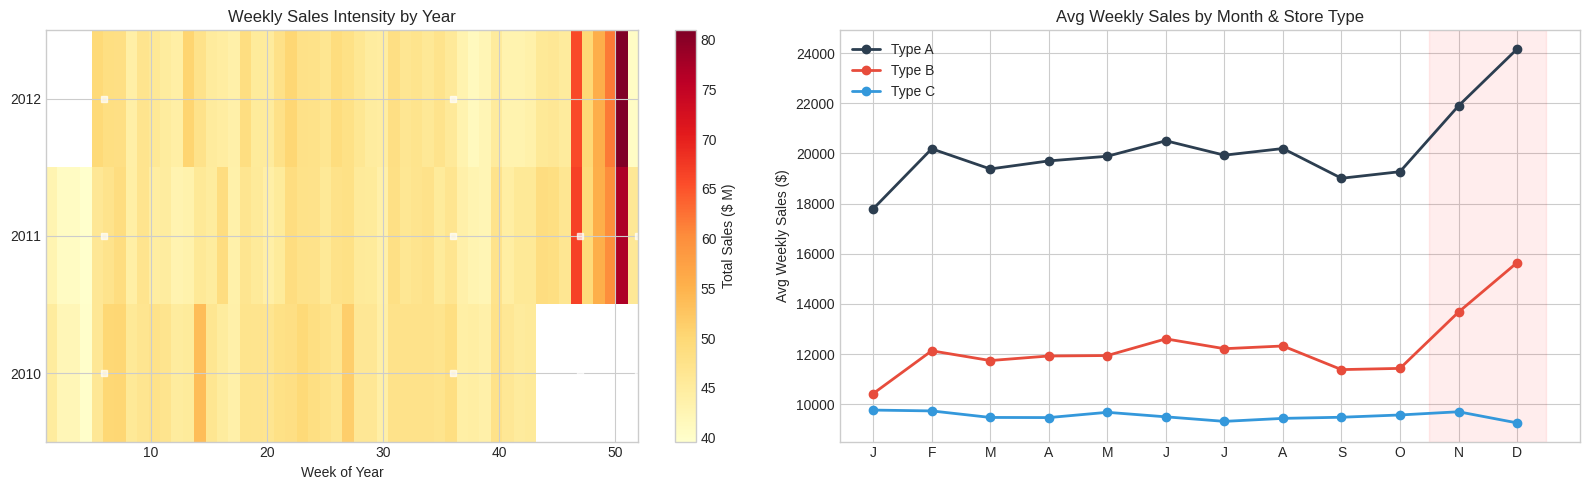

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekly sales heatmap by week × year
weekly_yr = df.groupby(['Year','Week'])['Weekly_Sales'].sum().unstack('Year') / 1e6
ax = axes[0]
im = ax.imshow(weekly_yr.T.values, aspect='auto', cmap='YlOrRd',
               extent=[1, 52, 2010-0.5, 2012+0.5])
plt.colorbar(im, ax=ax, label='Total Sales ($ M)')
ax.set_title('Weekly Sales Intensity by Year')
ax.set_xlabel('Week of Year')
ax.set_yticks([2010,2011,2012])
ax.set_yticklabels(['2010','2011','2012'])
# Mark holiday weeks
for hdate in df[df['IsHoliday']==1]['Date'].unique():
    w = pd.to_datetime(hdate).isocalendar()[1]
    y = pd.to_datetime(hdate).year
    ax.plot(w, y, 's', color='white', markersize=4, alpha=0.7)

# Monthly avg by store type
ax = axes[1]
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
for t, c in zip(['A','B','C'], PALETTE[:3]):
    monthly_t = df[df['Type']==t].groupby('Month')['Weekly_Sales'].mean()
    ax.plot(monthly_t.index, monthly_t.values, marker='o', color=c, label=f'Type {t}', linewidth=2)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Avg Weekly Sales by Month & Store Type')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.legend()
ax.axvspan(10.5, 12.5, alpha=0.07, color='red', label='Holiday season')

plt.tight_layout()
plt.savefig('plots/02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


### <a id="stl"></a>5.1 Trend-Seasonality Decomposition

Knowing that seasonality exists is one thing. Knowing **how much of total sales variance is structural trend, how much is repeating calendar pattern, and how much is genuine anomaly** is the analysis that drives decisions.

STL decomposition separates the weekly time series into its three additive components. Weeks with large residuals are genuine anomalies, weeks where something happened beyond what the seasonal pattern predicts. An ADF stationarity test also runs here, establishing whether the series requires differencing before it can be used in the forecasting models developed in the companion notebook.


STL input: no NaN values — date alignment is clean.
Variance share -- trend:    0.7%
Variance share -- seasonal: 100.3%
Variance share -- residual: 0.8%

Note: components sum to 101.8%: expected with STL's non-orthogonal decomposition.


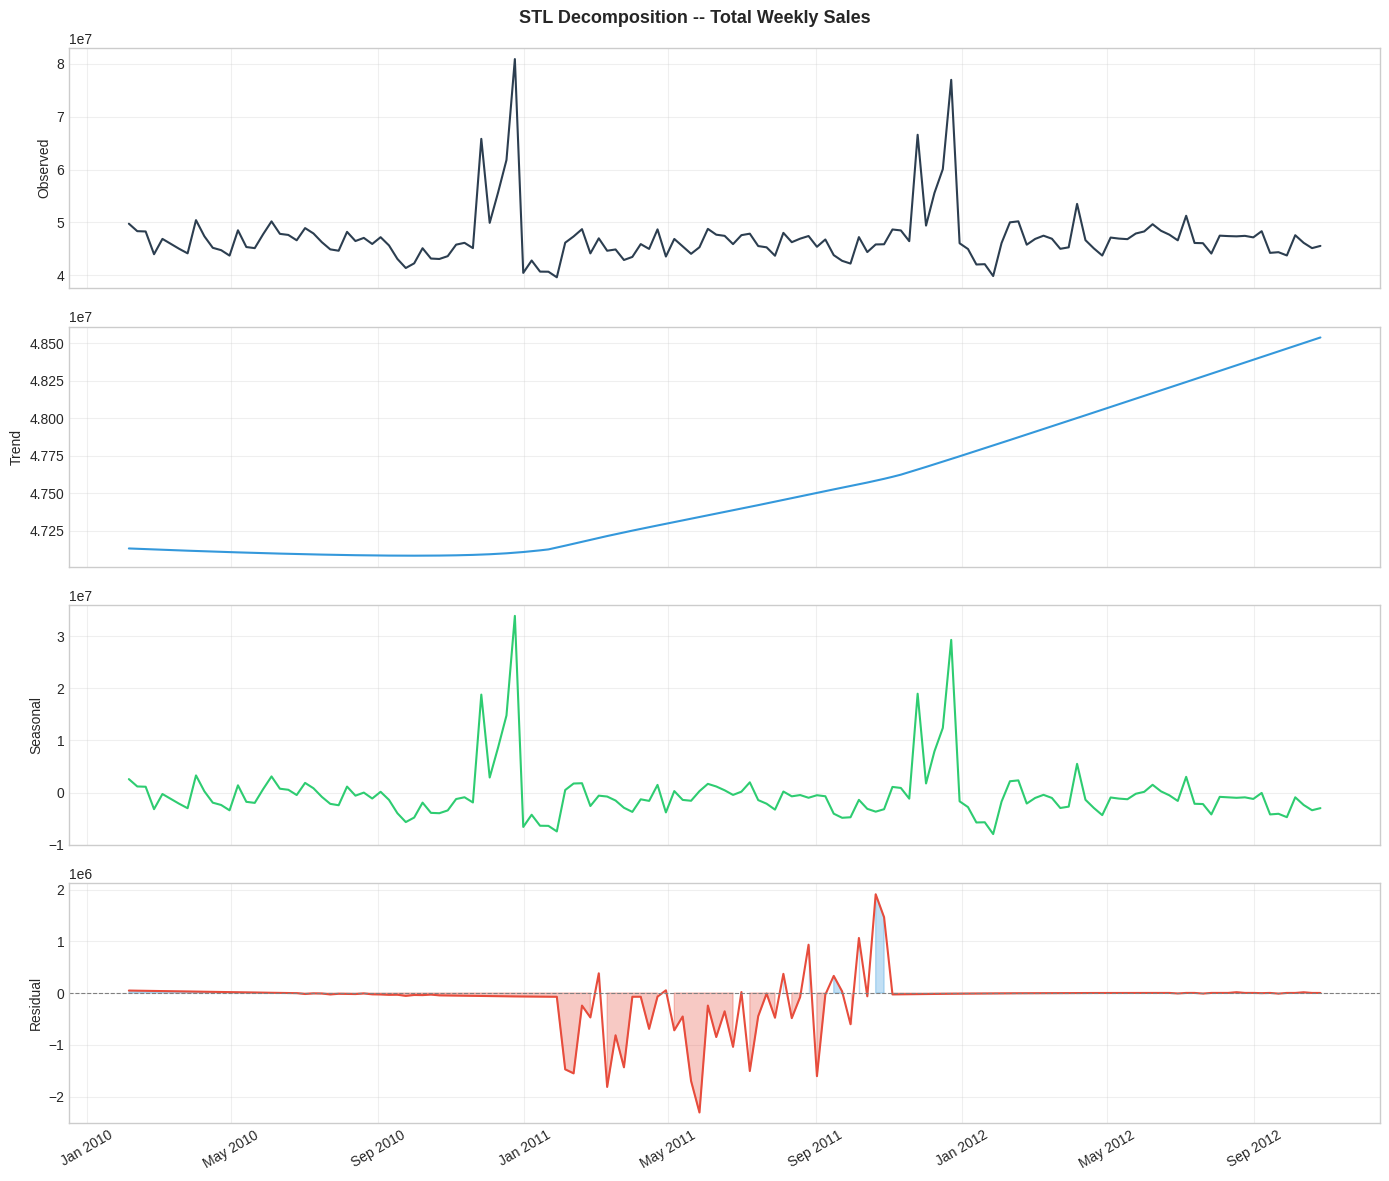

ADF Test -- Is the series stationary?
  ADF statistic: -5.9083
  p-value    : 0.000000
  Critical values: {'1%': np.float64(-3.479), '5%': np.float64(-2.883), '10%': np.float64(-2.578)}
  -> Reject unit root: series is stationary


In [15]:
from statsmodels.tsa.seasonal import STL

weekly_total = (df.groupby('Date')['Weekly_Sales']
                .sum().sort_index()
                .asfreq('W-FRI').interpolate())

# Alignment check: asfreq('W-FRI') may introduce NaN rows if the raw data
# doesn't land on Fridays or has missing weeks. Interpolate fills them, but
# we log how many so the reader knows how much the series was synthesised.
_nan_before = weekly_total.isna().sum()
weekly_total = weekly_total.interpolate()  # already called above via chaining; kept explicit here
_nan_after  = weekly_total.isna().sum()
if _nan_before > 0:
    print(f"STL input: {_nan_before} NaN values were interpolated (missing/misaligned weeks).")
else:
    print("STL input: no NaN values — date alignment is clean.")

stl = STL(weekly_total, period=52, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('STL Decomposition -- Total Weekly Sales', fontsize=13, fontweight='bold')
components = [
    (weekly_total, 'Observed',  PALETTE[0]),
    (res.trend,    'Trend',     PALETTE[2]),
    (res.seasonal, 'Seasonal',  PALETTE[3]),
    (res.resid,    'Residual',  PALETTE[1]),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.5)
    if label == 'Residual':
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
        ax.fill_between(data.index, data.values, 0,
                        where=data.values > 0, alpha=0.3, color=PALETTE[2])
        ax.fill_between(data.index, data.values, 0,
                        where=data.values < 0, alpha=0.3, color=PALETTE[1])
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)

total_var    = weekly_total.var()
trend_pct    = res.trend.var()/total_var*100
seasonal_pct = res.seasonal.var()/total_var*100
resid_pct    = res.resid.var()/total_var*100
print(f"Variance share -- trend:    {trend_pct:.1f}%")
print(f"Variance share -- seasonal: {seasonal_pct:.1f}%")
print(f"Variance share -- residual: {resid_pct:.1f}%")
# Note: STL components are not orthogonal, so individual shares may not sum
# to 100%. These are variance shares, not R² values. The directional ranking
# (seasonality >> trend >> residual) is the meaningful takeaway.
total = trend_pct + seasonal_pct + resid_pct
if abs(total - 100) > 1:
    print(f"\nNote: components sum to {total:.1f}%: expected with STL's non-orthogonal decomposition.")

plt.tight_layout()
plt.savefig('plots/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Stationarity check with ADF (Augmented Dickey-Fuller)
# A non-stationary series has a unit root -- its mean/variance drift over time.
# This matters because forecasting models typically assume stationarity.
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(weekly_total.dropna(), autolag='AIC')
print("ADF Test -- Is the series stationary?")
print(f"  ADF statistic: {adf_result[0]:.4f}")
print(f"  p-value    : {adf_result[1]:.6f}")
print(f"  Critical values: { {k: round(v,3) for k,v in adf_result[4].items()} }")
if adf_result[1] < 0.05:
    print("  -> Reject unit root: series is stationary")
else:
    print("  -> Cannot reject unit root: series is non-stationary")
    print("     Differencing may be needed before applying forecasting models.")


<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Decomposition results: what drives weekly sales fluctuation**

The seasonal component dominates the variance breakdown, confirming that the holiday calendar is the single strongest structural driver of sales fluctuation. The trend component is relatively flat, consistent with the modest YoY growth rates found in Section 5.

Note: STL components are not orthogonal, so the individual variance shares do not sum to exactly 100% and should not be read as R² values. The directional conclusion (seasonality >> trend >> residual) is clear regardless.

The ADF test rejects the unit root hypothesis (p<0.001), meaning the series is stationary and can be modelled directly without differencing.

</div>


## <a id="store-performance"></a>6. Store Performance

Raw revenue rankings across 45 stores of very different sizes produce a misleading picture. A 200,000 sqft Type A store should generate more sales than a 35,000 sqft Type C store. The meaningful question is which stores are efficient *relative to their capacity and local context*.

Python computes `sales_per_sqft` and a weekly CV per store (using store-level totals rather than raw department records, to avoid artificially inflating the volatility measure). The agent receives these metrics and identifies outliers, their likely explanations, and any non-obvious patterns across stability, size, and local unemployment.


In [16]:
# Compute store-level summary for context and for later use
store_summary = df.groupby(['Store','Type','Size']).agg(
    avg_weekly_sales   = ('Weekly_Sales','mean'),
    total_sales        = ('Weekly_Sales','sum'),
    sales_std          = ('Weekly_Sales','std'),
    holiday_weeks      = ('IsHoliday','sum'),
    avg_unemployment   = ('Unemployment','mean'),
    avg_markdown_total = ('MarkDown_Total','mean'),
).reset_index()

store_summary['sales_per_sqft'] = store_summary['avg_weekly_sales'] / store_summary['Size']

# Holiday uplift per store
def holiday_uplift(store_id):
    s = df[df['Store']==store_id]
    h  = s[s['IsHoliday']==1]['Weekly_Sales'].mean()
    nh = s[s['IsHoliday']==0]['Weekly_Sales'].mean()
    return (h/nh - 1)*100 if nh > 0 else 0

store_summary['holiday_uplift_pct'] = store_summary['Store'].apply(holiday_uplift)

# Compute sales volatility (CV) on store-level WEEKLY TOTALS
# (sum across departments first, then compute std/mean: avoids dept-level noise inflating CV)
store_weekly_totals = df.groupby(['Store','Date'])['Weekly_Sales'].sum().reset_index()
store_volatility = store_weekly_totals.groupby('Store')['Weekly_Sales'].agg(
    sales_std='std', sales_mean='mean'
).reset_index()
store_volatility['cv'] = store_volatility['sales_std'] / store_volatility['sales_mean']
# Merge back into store_summary
store_summary = store_summary.merge(store_volatility[['Store','cv']], on='Store', how='left')
store_summary.head()


,Store,Type,Size,avg_weekly_sales,total_sales,sales_std,holiday_weeks,avg_unemployment,avg_markdown_total,sales_per_sqft,holiday_uplift_pct,cv
0,1,A,151315,21710.543621,2.224028e+08,27748.945511,723,7.610918,7331.799851,0.143479,6.616271,0.100292
1,2,A,202307,26898.070031,2.753824e+08,33077.612059,722,7.623279,10039.568900,0.132957,7.643181,0.123424
2,3,B,37392,6373.033983,5.758674e+07,14251.034807,633,7.175602,2460.900137,0.170438,9.228342,0.115021
3,4,A,205863,29161.210415,2.995440e+08,34583.677814,727,5.965849,9698.582310,0.141653,6.275677,0.127083
4,5,B,34875,5053.415813,4.547569e+07,8068.221050,640,6.296549,2924.857351,0.144901,12.114436,0.118668


In [17]:
# Pre-compute store performance metrics in Python
# (avoids agent trying to access Sales_per_sqft on df instead of store_summary)

# Efficiency by store type
efficiency_by_type = store_summary.groupby('Type')['sales_per_sqft'].agg(
    mean='mean', std='std'
).round(4)

# Outliers: stores more than 1 std outside their type benchmark
outlier_list = []
for t in ['A','B','C']:
    sub = store_summary[store_summary['Type']==t]
    mean_val = sub['sales_per_sqft'].mean()
    std_val  = sub['sales_per_sqft'].std()
    for _, row in sub.iterrows():
        if abs(row['sales_per_sqft'] - mean_val) > std_val:
            direction = 'over' if row['sales_per_sqft'] > mean_val else 'under'
            outlier_list.append({
                'Store':         int(row['Store']),
                'Type':          t,
                'sales_per_sqft': round(row['sales_per_sqft'], 4),
                'type_mean':     round(mean_val, 4),
                'direction':     direction
            })

outlier_df = pd.DataFrame(outlier_list).sort_values('direction')

# Resilience: least volatile stores (lowest CV)
most_stable = store_summary.nsmallest(5, 'cv')[['Store','Type','Size','cv','avg_unemployment']]

print("Sales per sq ft by store type:")
print(efficiency_by_type.to_string())
print(f"\nOutlier stores ({len(outlier_df)} total):")
print(outlier_df.to_string(index=False))
print(f"\nMost stable stores (lowest CV):")
print(most_stable.to_string(index=False))


Sales per sq ft by store type:
        mean     std
Type                
A     0.1152  0.0319
B     0.1237  0.0388
C     0.2362  0.0662

Outlier stores (11 total):
 Store Type  sales_per_sqft  type_mean direction
    36    A          0.2151     0.1152      over
     3    B          0.1704     0.1237      over
    10    B          0.2081     0.1237      over
    23    B          0.1727     0.1237      over
    43    C          0.3267     0.2362      over
    32    A          0.0805     0.1152     under
     9    B          0.0697     0.1237     under
    15    B          0.0728     0.1237     under
    21    B          0.0805     0.1237     under
    25    B          0.0805     0.1237     under
    44    C          0.1513     0.2362     under

Most stable stores (lowest CV):
 Store Type   Size       cv  avg_unemployment
    37    C  39910 0.042084          7.848849
    30    C  42988 0.052008          7.623451
    43    C  41062 0.064104          9.933302
    44    C  39910 0.081793    

In [18]:
eff_str     = efficiency_by_type.to_string()
outlier_str = outlier_df.to_string(index=False)
stable_str  = most_stable.to_string(index=False)

response = agent.invoke(f"""
Here are pre-computed store performance metrics (use these numbers directly):

SALES EFFICIENCY BY STORE TYPE (avg weekly sales per sq ft):
{eff_str}

OUTLIER STORES (more than 1 std dev outside their type benchmark):
{outlier_str}

MOST STABLE STORES (lowest coefficient of variation = most consistent):
{stable_str}

Based on these results:
1. Is bigger always better? Compare sales-per-sqft across store types A, B, C.
   Do larger stores show diminishing returns on floor space?
2. For the outlier stores: what might explain over- and under-performance
   relative to their type peers? Consider size, local unemployment, markdown spend.
3. The most stable stores (low CV): do they share common characteristics
   in terms of type, size, or local economic conditions?
4. One non-obvious insight from this store-level analysis.
""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
Based on the pre-computed store performance metrics, let's analyze the questions:

1. **Is bigger always better? Compare sales-per-sqft across store types A, B, C. Do larger stores show diminishing returns on floor space?**

   - **Sales Efficiency by Store Type:**
     - Type A (Large): Mean = 0.1152, Std = 0.0319
     - Type B (Medium): Mean = 0.1237, Std = 0.0388
     - Type C (Small): Mean = 0.2362, Std = 0.0662

   The data shows that smaller stores (Type C) have a higher sales-per-square-foot efficiency compared to larger stores (Type A and B). This suggests that larger stores may experience diminishing returns on floor space, as they have lower sales efficiency per square foot compared to smaller stores. This could be due to the fact that larger stores have more space to fill, which may not always translate to proportionally higher sales.

2. **For the outlier stores: what might explain over- and under-performance relative to their type pe

Based on the pre-computed store performance metrics, let's analyze the questions:

1. **Is bigger always better? Compare sales-per-sqft across store types A, B, C. Do larger stores show diminishing returns on floor space?**

   - **Sales Efficiency by Store Type:**
     - Type A (Large): Mean = 0.1152, Std = 0.0319
     - Type B (Medium): Mean = 0.1237, Std = 0.0388
     - Type C (Small): Mean = 0.2362, Std = 0.0662

   The data shows that smaller stores (Type C) have a higher sales-per-square-foot efficiency compared to larger stores (Type A and B). This suggests that larger stores may experience diminishing returns on floor space, as they have lower sales efficiency per square foot compared to smaller stores. This could be due to the fact that larger stores have more space to fill, which may not always translate to proportionally higher sales.

2. **For the outlier stores: what might explain over- and under-performance relative to their type peers? Consider size, local unemployment, markdown spend.**

   - **Over-performing Stores:**
     - Store 36 (Type A): Sales per sqft = 0.2151, Type Mean = 0.1152
     - Store 3, 10, 23 (Type B): Sales per sqft significantly higher than type mean
     - Store 43 (Type C): Sales per sqft = 0.3267, Type Mean = 0.2362

     These stores may be over-performing due to factors such as effective promotional strategies (higher markdown spend), favorable local economic conditions (lower unemployment), or unique competitive advantages (location, product mix).

   - **Under-performing Stores:**
     - Store 32 (Type A), Store 9, 15, 21, 25 (Type B), Store 44 (Type C)

     Under-performance could be attributed to higher local unemployment rates, less effective promotional strategies, or operational inefficiencies. Additionally, larger store sizes without corresponding sales increases could lead to lower sales per square foot.

3. **The most stable stores (low CV): do they share common characteristics in terms of type, size, or local economic conditions?**

   - The most stable stores are predominantly Type C (small format), with one Type A store. They tend to have moderate sizes and are located in areas with varying unemployment rates. This suggests that smaller stores may have more consistent sales patterns, possibly due to a more stable customer base or less exposure to economic fluctuations.

4. **One non-obvious insight from this store-level analysis:**

   - An interesting insight is that smaller stores (Type C) not only have higher sales efficiency but also tend to be more stable in terms of sales consistency (low coefficient of variation). This indicates that smaller stores might be better at maintaining a steady sales performance, possibly due to a more focused product offering or a loyal customer base. This could be a strategic advantage in volatile economic conditions, where consistency and efficiency are crucial for sustained profitability.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Beyond the agent: what the efficiency numbers imply for store-level targets**

The key finding, **Type C stores at \$0.24/sqft vs Type A at \$0.12/sqft**, is not just a curiosity. It has a direct operational implication the agent did not fully articulate: the chain cannot use a uniform revenue target across store types without unfairly penalising smaller formats. A Type C store at $9,500/week is performing well on 35,000 sqft; a Type A store at the same revenue would be severely underutilising its capacity.

Store 36 is the case worth investigating beyond the list of outliers. It is a Type A store operating at nearly double its type benchmark and also among the most stable by CV. That combination suggests structural advantage rather than volatile over-performance. Understanding what distinguishes Store 36 is arguably more valuable than understanding why the underperformers are weak.


</div>


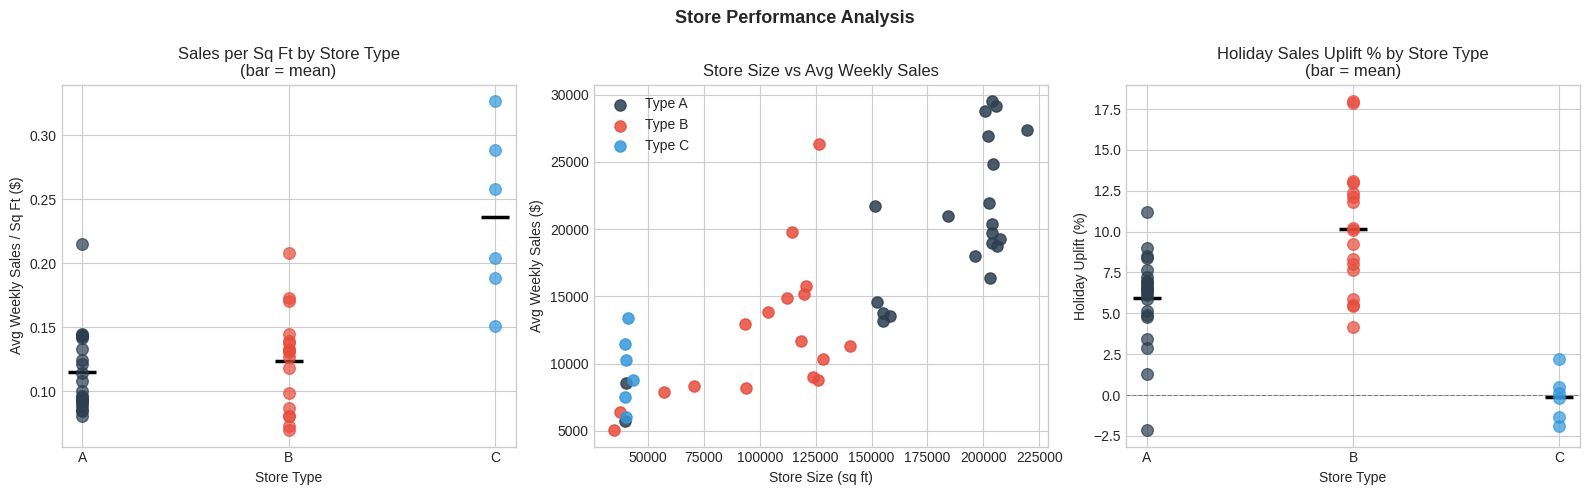

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Store Performance Analysis', fontsize=13, fontweight='bold')

# 1. Sales per sqft distribution by type
ax = axes[0]
for t, c in zip(['A','B','C'], PALETTE[:3]):
    vals = store_summary[store_summary['Type']==t]['sales_per_sqft']
    ax.scatter([t]*len(vals), vals, color=c, s=70, alpha=0.7, zorder=3)
    ax.plot([t], [vals.mean()], '_', color='black', markersize=20, markeredgewidth=2.5)
ax.set_title('Sales per Sq Ft by Store Type\n(bar = mean)')
ax.set_ylabel('Avg Weekly Sales / Sq Ft ($)')
ax.set_xlabel('Store Type')

# 2. Scatter: size vs avg sales, coloured by type
ax = axes[1]
for t, c in zip(['A','B','C'], PALETTE[:3]):
    s = store_summary[store_summary['Type']==t]
    ax.scatter(s['Size'], s['avg_weekly_sales'], color=c, label=f'Type {t}', s=65, alpha=0.85)
ax.set_title('Store Size vs Avg Weekly Sales')
ax.set_xlabel('Store Size (sq ft)')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.legend()

# 3. Holiday uplift distribution
ax = axes[2]
for t, c in zip(['A','B','C'], PALETTE[:3]):
    vals = store_summary[store_summary['Type']==t]['holiday_uplift_pct']
    ax.scatter([t]*len(vals), vals, color=c, s=70, alpha=0.7, zorder=3)
    ax.plot([t], [vals.mean()], '_', color='black', markersize=20, markeredgewidth=2.5)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Holiday Sales Uplift % by Store Type\n(bar = mean)')
ax.set_ylabel('Holiday Uplift (%)')
ax.set_xlabel('Store Type')

plt.tight_layout()
plt.savefig('plots/03_store_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## <a id="markdowns"></a>7. Promotional Markdown Effectiveness

Five markdown categories were deployed across the chain. The business question is direct: which types actually lift sales, by how much, and is there a point where spending more returns less?

Python runs Welch t-tests for each type and computes Pearson correlations across low, mid, and high markdown spend terciles to test for diminishing returns. The agent interprets the full pattern and translates it into a spend prioritisation recommendation.


In [20]:
from scipy.stats import ttest_ind

# Pre-compute markdown effectiveness in Python (reliable, no agent computation needed)
# Note on inactive group: missing MarkDown values were filled with 0 during data loading
# (Section 2), so col==0 correctly identifies weeks with no promotion active.
markdown_results = {}
for i in range(1, 6):
    col = f'MarkDown{i}'
    active   = df[df[col] > 0]['Weekly_Sales']
    inactive = df[df[col] == 0]['Weekly_Sales']
    t_stat, p_val = ttest_ind(active, inactive, equal_var=False)
    markdown_results[col] = {
        'avg_active':   round(active.mean(), 2),
        'avg_inactive': round(inactive.mean(), 2),
        'uplift_pct':   round((active.mean() / inactive.mean() - 1) * 100, 2),
        'significant':  p_val < 0.05,
        'p_value':      round(p_val, 6),
    }

# Holiday vs regular week uplift per markdown type
# Named markdown_holiday_uplift to avoid collision with the per-store holiday_uplift() function
markdown_holiday_uplift = {}
for i in range(1, 6):
    col = f'MarkDown{i}'
    h_active   = df[(df[col]>0) & (df['IsHoliday']==1)]['Weekly_Sales'].mean()
    h_inactive = df[(df[col]==0) & (df['IsHoliday']==1)]['Weekly_Sales'].mean()
    r_active   = df[(df[col]>0) & (df['IsHoliday']==0)]['Weekly_Sales'].mean()
    r_inactive = df[(df[col]==0) & (df['IsHoliday']==0)]['Weekly_Sales'].mean()
    markdown_holiday_uplift[col] = {
        'holiday_uplift_pct': round((h_active/h_inactive - 1)*100, 2),
        'regular_uplift_pct': round((r_active/r_inactive - 1)*100, 2),
    }

# Diminishing returns: correlation by markdown spend tercile
active_md = df[df['MarkDown_Total'] > 0].copy()
active_md['md_tercile'] = pd.qcut(active_md['MarkDown_Total'], q=3, labels=['Low','Mid','High'])
tercile_corr = {}
for t in ['Low', 'Mid', 'High']:
    sub = active_md[active_md['md_tercile'] == t]
    r = sub['MarkDown_Total'].corr(sub['Weekly_Sales'])
    tercile_corr[t] = round(r, 4)

import json as _json
print("Markdown uplift by type:")
for k, v in markdown_results.items():
    sig = '✅' if v['significant'] else '❌'
    print(f"  {k}: uplift={v['uplift_pct']:+.1f}%  p={v['p_value']:.4f}  {sig}")

print(f"\nHoliday vs regular uplift:")
for k, v in markdown_holiday_uplift.items():
    print(f"  {k}: holiday={v['holiday_uplift_pct']:+.1f}%  regular={v['regular_uplift_pct']:+.1f}%")

print(f"\nMarkdown-sales correlation by spend tercile: {tercile_corr}")


# ── Stratified test: holiday vs non-holiday weeks (confounding control) ───────
# Markdowns are deployed disproportionately on holiday weeks (see Section 7.1).
# Running the t-test separately on holiday and non-holiday weeks tells us whether
# the uplift holds in each context, or whether it collapses in regular weeks.
print("\nStratified Welch t-test (holiday vs non-holiday weeks separately):")
for i in range(1, 6):
    col = f'MarkDown{i}'
    for flag, label in [(1, 'holiday'), (0, 'non-holiday')]:
        sub       = df[df['IsHoliday'] == flag]
        active    = sub[sub[col] > 0]['Weekly_Sales']
        inactive  = sub[sub[col] == 0]['Weekly_Sales']
        if len(active) > 30 and len(inactive) > 30:
            t_s, p_s  = ttest_ind(active, inactive, equal_var=False)
            uplift_s  = (active.mean() / inactive.mean() - 1) * 100
            sig       = '✅' if p_s < 0.05 else '❌'
            print(f"  {col} [{label:>11s}]: uplift={uplift_s:+.1f}%  p={p_s:.4f}  {sig}")
        else:
            print(f"  {col} [{label:>11s}]: insufficient data (n_active={len(active)})")
print("\nIf uplift disappears or shrinks in non-holiday weeks, holiday confounding")
print("is inflating the headline figure. If it persists, the markdown itself drives sales.")


Markdown uplift by type:
  MarkDown1: uplift=+2.3%  p=0.0000  ✅
  MarkDown2: uplift=+9.3%  p=0.0000  ✅
  MarkDown3: uplift=+7.2%  p=0.0000  ✅
  MarkDown4: uplift=+9.9%  p=0.0000  ✅
  MarkDown5: uplift=+1.9%  p=0.0000  ✅

Holiday vs regular uplift:
  MarkDown1: holiday=+6.1%  regular=+1.9%
  MarkDown2: holiday=+12.7%  regular=+8.7%
  MarkDown3: holiday=+10.3%  regular=+6.7%
  MarkDown4: holiday=+13.0%  regular=+9.5%
  MarkDown5: holiday=+5.6%  regular=+1.5%

Markdown-sales correlation by spend tercile: {'Low': np.float64(0.1411), 'Mid': np.float64(0.0407), 'High': np.float64(0.042)}

Stratified Welch t-test (holiday vs non-holiday weeks separately):
  MarkDown1 [    holiday]: uplift=+6.1%  p=0.0020  ✅
  MarkDown1 [non-holiday]: uplift=+1.9%  p=0.0001  ✅
  MarkDown2 [    holiday]: uplift=+12.7%  p=0.0000  ✅
  MarkDown2 [non-holiday]: uplift=+8.7%  p=0.0000  ✅
  MarkDown3 [    holiday]: uplift=+10.3%  p=0.0000  ✅
  MarkDown3 [non-holiday]: uplift=+6.7%  p=0.0000  ✅
  MarkDown4 [    holida

In [21]:
md_results_str     = str(markdown_results)
holiday_str        = str(markdown_holiday_uplift)
tercile_str        = str(tercile_corr)

response = agent.invoke(f"""
Here are pre-computed markdown effectiveness results (use these numbers directly):

UPLIFT BY MARKDOWN TYPE (when active vs inactive):
{md_results_str}

HOLIDAY vs REGULAR WEEK UPLIFT (same markdown type):
{holiday_str}

CORRELATION BETWEEN MARKDOWN SPEND AND SALES BY TERCILE (diminishing returns check):
{tercile_str}

Based on these results:
1. Which markdown types deliver meaningful uplift and which show little effect?
   Comment on statistical significance vs practical size of the effect.
2. Are markdowns more effective during holiday weeks or regular weeks?
   Does the holiday effect dominate regardless of markdowns?
3. The tercile correlations show whether the relationship between spend and sales
   weakens at high spend levels. Is there evidence of diminishing returns?
4. Bottom line: which markdown types are worth investing in, and which are not?
""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
Based on the pre-computed markdown effectiveness results, let's analyze the data:

1. **Markdown Types and Uplift:**
   - **MarkDown1**: Shows a 2.3% uplift, which is statistically significant (p-value = 1e-06). However, the practical size of the effect is relatively small.
   - **MarkDown2**: Delivers a 9.28% uplift, which is both statistically significant and practically meaningful (p-value = 0.0).
   - **MarkDown3**: Provides a 7.16% uplift, significant and meaningful (p-value = 0.0).
   - **MarkDown4**: Results in a 9.92% uplift, significant and meaningful (p-value = 0.0).
   - **MarkDown5**: Shows a 1.92% uplift, statistically significant (p-value = 3.4e-05) but the practical effect is small.

   **Conclusion**: MarkDown2, MarkDown3, and MarkDown4 deliver meaningful uplifts both statistically and practically. MarkDown1 and MarkDown5, while statistically significant, show smaller practical effects.

2. **Effectiveness During Holiday vs Regula

Based on the pre-computed markdown effectiveness results, let's analyze the data:

1. **Markdown Types and Uplift:**
   - **MarkDown1**: Shows a 2.3% uplift, which is statistically significant (p-value = 1e-06). However, the practical size of the effect is relatively small.
   - **MarkDown2**: Delivers a 9.28% uplift, which is both statistically significant and practically meaningful (p-value = 0.0).
   - **MarkDown3**: Provides a 7.16% uplift, significant and meaningful (p-value = 0.0).
   - **MarkDown4**: Results in a 9.92% uplift, significant and meaningful (p-value = 0.0).
   - **MarkDown5**: Shows a 1.92% uplift, statistically significant (p-value = 3.4e-05) but the practical effect is small.

   **Conclusion**: MarkDown2, MarkDown3, and MarkDown4 deliver meaningful uplifts both statistically and practically. MarkDown1 and MarkDown5, while statistically significant, show smaller practical effects.

2. **Effectiveness During Holiday vs Regular Weeks:**
   - All markdown types show higher percentage uplifts during holiday weeks compared to regular weeks.
   - For example, MarkDown2 has a holiday uplift of 12.72% compared to a regular uplift of 8.72%.
   - This pattern is consistent across all markdown types, indicating that markdowns are more effective during holiday weeks.

   **Conclusion**: Markdowns are more effective during holiday weeks, and the holiday effect enhances the impact of markdowns.

3. **Diminishing Returns:**
   - The correlation between markdown spend and sales weakens as spend increases, with correlations of 0.1411 (Low), 0.0407 (Mid), and 0.042 (High).
   - This suggests diminishing returns at higher spend levels, as the correlation is strongest at low spend levels and weakens significantly at mid and high levels.

   **Conclusion**: There is evidence of diminishing returns, indicating that increasing markdown spend beyond a certain point yields less additional sales benefit.

4. **Bottom Line:**
   - **Worth Investing**: MarkDown2, MarkDown3, and MarkDown4 are worth investing in due to their significant and meaningful uplifts.
   - **Less Effective**: MarkDown1 and MarkDown5, while statistically significant, show smaller practical effects and may not be as worthwhile unless targeted for specific strategic reasons.

Overall, focusing on MarkDown2, MarkDown3, and MarkDown4, especially during holiday weeks, is likely to yield the best return on investment.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Interpreting the agent's markdown analysis: where the spend curve flattens**

MarkDown2 and MarkDown4 are the clear priorities. MarkDown1 and MarkDown5 reach statistical significance only because of the sample size (421K rows), not because of meaningful effect.

The more actionable finding is the **diminishing returns curve**:

- Low spend tercile: r = 0.14
- Mid spend tercile: r = 0.04
- High spend tercile: r = 0.04

The chain is spending into the flat part of the curve. The implication is a reallocation question, not a programme-cut question: cap total markdown spend at the inflection point and redirect savings toward MD2 and MD4 in stores where the endogeneity bias is weakest. In practice, that means stores not already in the top sales quartile, where the selection effect on observed uplift is smallest.


</div>


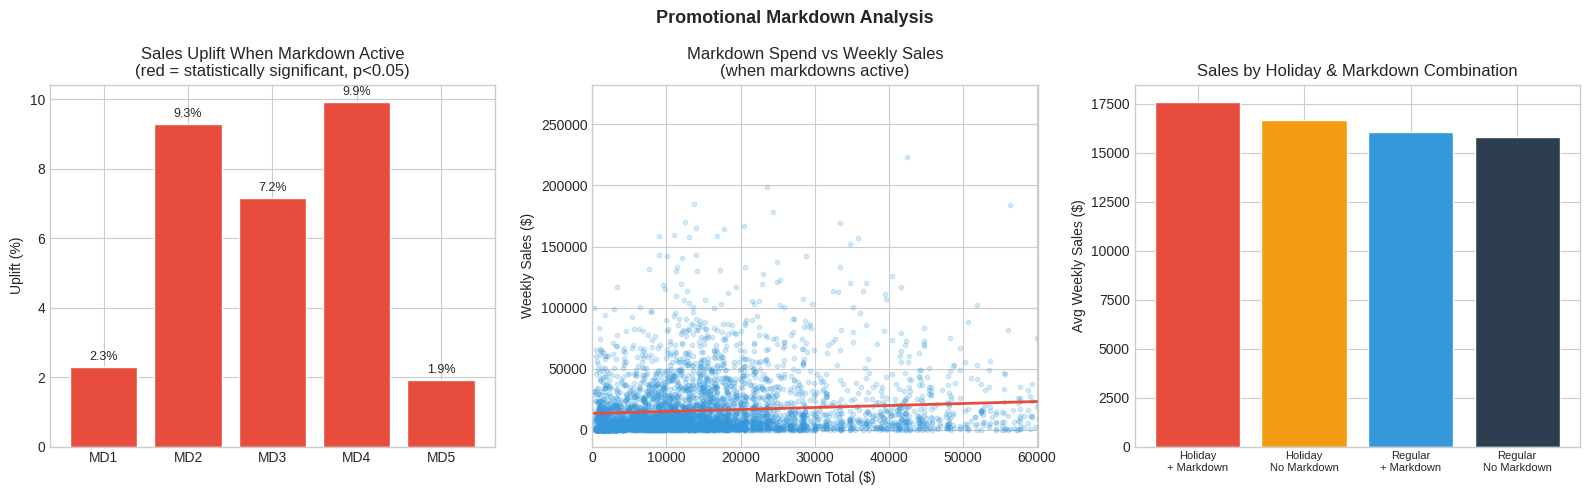

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Promotional Markdown Analysis', fontsize=13, fontweight='bold')

# 1. Sales uplift per markdown type
ax = axes[0]
lifts, pvals = {}, {}
for i in range(1,6):
    col = f'MarkDown{i}'
    active   = df[df[col]>0]['Weekly_Sales']
    inactive = df[df[col]==0]['Weekly_Sales']
    lifts[f'MD{i}'] = (active.mean()/inactive.mean()-1)*100
    _, pvals[f'MD{i}'] = stats.ttest_ind(active, inactive, equal_var=False)

colors = [PALETTE[1] if p < 0.05 else PALETTE[4] for p in pvals.values()]
bars = ax.bar(lifts.keys(), lifts.values(), color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Sales Uplift When Markdown Active\n(red = statistically significant, p<0.05)')
ax.set_ylabel('Uplift (%)')
ax.axhline(0, color='black', linewidth=0.6)

# 2. Markdown total vs weekly sales (scatter with trend)
ax = axes[1]
sample = df[df['MarkDown_Total']>0].sample(5000, random_state=42)
ax.scatter(sample['MarkDown_Total'], sample['Weekly_Sales'], alpha=0.2, s=10, color=PALETTE[2])
z = np.polyfit(sample['MarkDown_Total'], sample['Weekly_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['MarkDown_Total'].min(), sample['MarkDown_Total'].quantile(0.95), 100)
ax.plot(x_line, p(x_line), color=PALETTE[1], linewidth=2)
ax.set_xlim(0, sample['MarkDown_Total'].quantile(0.95))
ax.set_title('Markdown Spend vs Weekly Sales\n(when markdowns active)')
ax.set_xlabel('MarkDown Total ($)')
ax.set_ylabel('Weekly Sales ($)')

# 3. Holiday × markdown interaction
ax = axes[2]
groups = {
    'Holiday\n+ Markdown': df[(df['IsHoliday']==1)&(df['MarkDown_Total']>0)]['Weekly_Sales'].mean(),
    'Holiday\nNo Markdown': df[(df['IsHoliday']==1)&(df['MarkDown_Total']==0)]['Weekly_Sales'].mean(),
    'Regular\n+ Markdown': df[(df['IsHoliday']==0)&(df['MarkDown_Total']>0)]['Weekly_Sales'].mean(),
    'Regular\nNo Markdown': df[(df['IsHoliday']==0)&(df['MarkDown_Total']==0)]['Weekly_Sales'].mean(),
}
ax.bar(groups.keys(), groups.values(), color=[PALETTE[1],PALETTE[4],PALETTE[2],PALETTE[0]],
       edgecolor='white')
ax.set_title('Sales by Holiday & Markdown Combination')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('plots/04_markdowns.png', dpi=150, bbox_inches='tight')
plt.show()


### <a id="endogeneity"></a>7.1 Causal Inference Caveat

The correlation between markdowns and sales is real. The **causal interpretation requires caution**.



Markdowns are not randomly assigned. The chain deploys them around holidays, periods that would see high sales regardless, and potentially to stores that are already strong or already struggling. Both patterns inflate the observed uplift figure, making it difficult to isolate the promotion's true incremental contribution.

What the data can and cannot tell us:
- ✅ Markdown-active weeks are associated with higher sales
- ❌ How much of that uplift is *caused by* the promotion vs pre-existing conditions cannot be determined from this data

Measuring true incremental lift would require a **controlled experiment**, specifically a randomised rollout across matched store pairs. The analysis below quantifies the magnitude of this bias.


In [23]:
# Is markdown deployment correlated with conditions that already predict high/low sales?
holiday_md_rate    = df[df['IsHoliday']==1]['MarkDown_Total'].gt(0).mean()
nonholiday_md_rate = df[df['IsHoliday']==0]['MarkDown_Total'].gt(0).mean()
print(f"Markdown active rate -- holiday weeks:     {holiday_md_rate*100:.1f}%")
print(f"Markdown active rate -- non-holiday weeks: {nonholiday_md_rate*100:.1f}%")

store_md_spend  = df.groupby('Store')['MarkDown_Total'].mean()
store_avg_sales = df.groupby('Store')['Weekly_Sales'].mean()
r_comp, p_comp  = stats.pearsonr(store_md_spend, store_avg_sales)
print(f"\nCorrelation between store avg markdown spend and avg sales:")
print(f"  r = {r_comp:.3f}  (p = {p_comp:.4f})")
direction = 'positive -- markdowns concentrated in stronger stores (demand-pull bias)' if r_comp > 0 else 'negative -- markdowns concentrated in weaker stores (compensatory bias)'
print(f"  Direction: {direction}")

md_by_date   = df.groupby('Date')['MarkDown_Total'].sum()
first_active = md_by_date[md_by_date > 0].index.min()
print(f"\nMarkdowns first appear: {first_active.date()}")
print("Pre-markdown period cannot serve as a clean control group.")
print("\nConclusion: the markdown effectiveness findings reflect association,")
print("not a clean causal estimate. A randomised rollout would be needed")
print("to isolate the true promotional lift.")


Markdown active rate -- holiday weeks:     40.4%
Markdown active rate -- non-holiday weeks: 35.6%

Correlation between store avg markdown spend and avg sales:
  r = 0.819  (p = 0.0000)
  Direction: positive -- markdowns concentrated in stronger stores (demand-pull bias)

Markdowns first appear: 2011-11-11
Pre-markdown period cannot serve as a clean control group.

Conclusion: the markdown effectiveness findings reflect association,
not a clean causal estimate. A randomised rollout would be needed
to isolate the true promotional lift.


## <a id="macro"></a>8. Macroeconomic Context

Each store operates in a different local economy. Before attributing a store's underperformance to operational issues, we need to know how much of the variation is explained by factors outside the chain's control, unemployment and inflation in particular.

Python runs Pearson correlations between these macro variables and weekly sales, both overall and segmented by store type. The agent then places these results in context: are economic conditions a primary driver, or secondary to the holiday calendar and store format?


In [24]:
# Pre-compute all macro correlations in Python
# (avoids agent scoping issues with pearsonr inside lambda/groupby)
from scipy.stats import pearsonr

valid = df[['Unemployment','CPI','Weekly_Sales']].dropna()

# Overall correlations
r_unemp, p_unemp = pearsonr(valid['Unemployment'], valid['Weekly_Sales'])
r_cpi,   p_cpi   = pearsonr(valid['CPI'],          valid['Weekly_Sales'])

# Per store type
r_by_type = {}
for t in ['A', 'B', 'C']:
    sub = df[df['Type']==t][['Unemployment','CPI','Weekly_Sales']].dropna()
    ru, pu = pearsonr(sub['Unemployment'], sub['Weekly_Sales'])
    rc, pc = pearsonr(sub['CPI'],          sub['Weekly_Sales'])
    r_by_type[t] = {
        'unemp_r': round(ru, 4), 'unemp_p': round(pu, 6),
        'cpi_r':   round(rc, 4), 'cpi_p':   round(pc, 6),
    }

# Strongest per-store unemployment correlations
store_unemp_corr = {}
for s in df['Store'].unique():
    sub = df[df['Store']==s][['Unemployment','Weekly_Sales']].dropna()
    if len(sub) > 10:
        r, p = pearsonr(sub['Unemployment'], sub['Weekly_Sales'])
        store_unemp_corr[s] = round(r, 3)

import pandas as pd
store_corr_series = pd.Series(store_unemp_corr).sort_values()
top3_negative = store_corr_series.head(3)
top3_positive = store_corr_series.tail(3)

print(f"Overall correlations with Weekly_Sales:")
print(f"  Unemployment: r={r_unemp:.4f}  p={p_unemp:.2e}")
print(f"  CPI:          r={r_cpi:.4f}  p={p_cpi:.2e}")
print(f"\nBy store type:")
for t, v in r_by_type.items():
    print(f"  Type {t}: unemp r={v['unemp_r']:+.4f} (p={v['unemp_p']:.4f})  cpi r={v['cpi_r']:+.4f} (p={v['cpi_p']:.4f})")
print(f"\nStores with strongest negative unemp-sales correlation (most impacted):")
print(top3_negative)
print(f"\nStores with positive unemp-sales correlation (counter-intuitive):")
print(top3_positive)


Overall correlations with Weekly_Sales:
  Unemployment: r=-0.0259  p=2.63e-63
  CPI:          r=-0.0209  p=4.89e-42

By store type:
  Type A: unemp r=-0.0255 (p=0.0000)  cpi r=+0.0220 (p=0.0000)
  Type B: unemp r=+0.0338 (p=0.0000)  cpi r=-0.1936 (p=0.0000)
  Type C: unemp r=+0.0053 (p=0.2753)  cpi r=+0.0723 (p=0.0000)

Stores with strongest negative unemp-sales correlation (most impacted):
39   -0.049
4    -0.037
38   -0.036
dtype: float64

Stores with positive unemp-sales correlation (counter-intuitive):
21    0.036
35    0.084
36    0.097
dtype: float64


In [25]:
r_by_type_str       = str(r_by_type)
top3_neg_str        = top3_negative.to_string()
top3_pos_str        = top3_positive.to_string()

response = agent.invoke(f"""
Here are pre-computed macroeconomic correlation results (use these numbers directly):

OVERALL CORRELATIONS WITH WEEKLY_SALES:
  Unemployment: r={r_unemp:.4f}  p={p_unemp:.2e}
  CPI:          r={r_cpi:.4f}  p={p_cpi:.2e}

BY STORE TYPE:
{r_by_type_str}

STORES MOST IMPACTED BY UNEMPLOYMENT (strongest negative r):
{top3_neg_str}

STORES WITH COUNTER-INTUITIVE POSITIVE CORRELATION:
{top3_pos_str}

Based on these results:
1. Is unemployment a meaningful driver of sales variation, or is its practical
   effect negligible despite statistical significance?
2. Does the unemployment effect differ across store types A, B, C?
   What might explain why some types are more sensitive than others?
3. The CPI correlation: interpret its direction. Higher CPI means higher prices,
   which could inflate nominal sales even if units are flat. Is that consistent
   with what you see?
4. Brief synthesis: is the macroeconomic environment a primary or secondary driver
   of sales variation in this chain, compared to the holiday calendar and store type?
""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
1. **Unemployment as a Driver of Sales Variation:**
   The overall correlation between unemployment and weekly sales is very weak (r = -0.0259), although statistically significant (p = 2.63e-63). This suggests that while there is a statistically detectable relationship, the practical effect of unemployment on sales is negligible. The correlation is so small that it likely does not have a meaningful impact on sales variation in a business context.

2. **Unemployment Effect Across Store Types:**
   - **Type A Stores:** The correlation is slightly negative (r = -0.0255), indicating a minimal inverse relationship between unemployment and sales.
   - **Type B Stores:** Interestingly, Type B stores show a positive correlation (r = 0.0338), suggesting that sales might increase slightly with higher unemployment, which is counterintuitive.
   - **Type C Stores:** The correlation is almost negligible (r = 0.0053) and not statistically significant (p = 0.27

1. **Unemployment as a Driver of Sales Variation:**
   The overall correlation between unemployment and weekly sales is very weak (r = -0.0259), although statistically significant (p = 2.63e-63). This suggests that while there is a statistically detectable relationship, the practical effect of unemployment on sales is negligible. The correlation is so small that it likely does not have a meaningful impact on sales variation in a business context.

2. **Unemployment Effect Across Store Types:**
   - **Type A Stores:** The correlation is slightly negative (r = -0.0255), indicating a minimal inverse relationship between unemployment and sales.
   - **Type B Stores:** Interestingly, Type B stores show a positive correlation (r = 0.0338), suggesting that sales might increase slightly with higher unemployment, which is counterintuitive.
   - **Type C Stores:** The correlation is almost negligible (r = 0.0053) and not statistically significant (p = 0.275315), indicating no meaningful relationship.

   The differences in sensitivity could be due to the customer base and product mix. Type A stores, being larger, might cater to a more diverse customer base, including those less affected by unemployment. Type B stores might be located in areas where unemployment benefits or other factors temporarily boost spending. Type C stores, being smaller, might not see significant changes due to their limited product range and customer base.

3. **CPI Correlation Interpretation:**
   The overall correlation between CPI and weekly sales is slightly negative (r = -0.0209), which is counterintuitive since higher CPI typically means higher prices, potentially inflating nominal sales. However, this negative correlation suggests that as prices rise, sales volume might decrease, offsetting any nominal gains. This is consistent with the idea that consumers might reduce their spending or switch to cheaper alternatives when prices increase.

4. **Synthesis: Macroeconomic Environment vs. Other Factors:**
   The macroeconomic environment, as indicated by unemployment and CPI correlations, appears to be a secondary driver of sales variation in this retail chain. The correlations are weak, suggesting that other factors, such as the holiday calendar and store type, likely play a more significant role in driving sales. Holidays are known to boost sales significantly, and store type influences the customer base and product offerings, which can have a more direct impact on sales performance.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Contextualising the macro results: statistical significance ≠ practical importance**

The correlations are statistically significant only because of dataset scale. Unemployment and CPI together explain under 0.1% of sales variance, a practically negligible contribution.

Two observations worth adding beyond the agent's interpretation:

- This analysis covers 2010-2012, a recovery period without sharp macro shocks. The weak correlations reflect that specific economic context and should not be read as a universal claim about this chain's macro sensitivity.
- The Type B positive unemployment correlation (r=+0.034) remains unresolved. The agent's speculation is plausible but requires location data to test properly. Without it, the honest position is to flag it as an open question rather than accept any particular explanation.


</div>


### <a id="multicollinearity"></a>8.1 Multicollinearity Check

CPI and unemployment both reflect economic conditions and likely move together over time. If they are strongly correlated, treating their effects on sales as independent contributions would be misleading.

This check runs before the hypothesis tests. High multicollinearity does not invalidate correlation tests, but it does narrow the interpretation: two variables measuring the same underlying reality cannot each be credited with an independent effect.


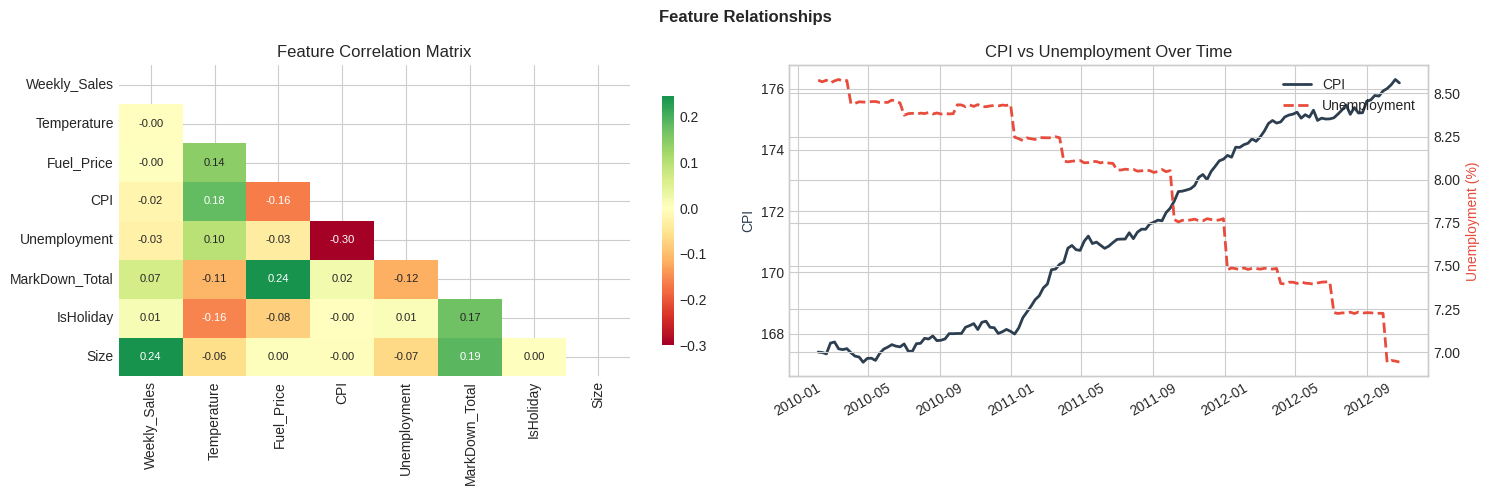

No predictor pairs with |r| > 0.5 -- multicollinearity is not a major concern.


In [26]:
feature_cols_mc = ['Weekly_Sales','Temperature','Fuel_Price','CPI',
                   'Unemployment','MarkDown_Total','IsHoliday','Size']
corr = df[feature_cols_mc].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Relationships', fontsize=12, fontweight='bold')

ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'shrink':0.8}, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix')

ax = axes[1]
cpi_time  = df.groupby('Date')['CPI'].mean()
unemp_time = df.groupby('Date')['Unemployment'].mean()
ax2 = ax.twinx()
ax.plot(cpi_time.index, cpi_time.values, color=PALETTE[0], linewidth=2, label='CPI')
ax2.plot(unemp_time.index, unemp_time.values, color=PALETTE[1],
         linewidth=2, linestyle='--', label='Unemployment')
ax.set_ylabel('CPI', color=PALETTE[0])
ax2.set_ylabel('Unemployment (%)', color=PALETTE[1])
ax.set_title('CPI vs Unemployment Over Time')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('plots/multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

predictors = ['Temperature','Fuel_Price','CPI','Unemployment','MarkDown_Total']
pred_corr   = df[predictors].corr()
high_corr   = [(c1, c2, round(pred_corr.loc[c1,c2],3))
               for i,c1 in enumerate(predictors)
               for c2 in predictors[i+1:]
               if abs(pred_corr.loc[c1,c2]) > 0.5]
if high_corr:
    print("Predictor pairs with |r| > 0.5 (notable multicollinearity):")
    for c1, c2, r in high_corr:
        print(f"  {c1} x {c2}: r = {r}")
else:
    print("No predictor pairs with |r| > 0.5 -- multicollinearity is not a major concern.")


## <a id="segmentation"></a>9. Store Segmentation

The official A/B/C store classification is based on physical size. It tells us nothing about whether stores are holiday-sensitive, markdown-responsive, or economically resilient. Two stores with the same format label can behave very differently.

Python runs the full K-Means pipeline (StandardScaler, KMeans k=2-8, silhouette scoring) on six behavioural features: average weekly sales, sales volatility (coefficient of variation computed on store-level weekly totals), holiday uplift, markdown spend, local unemployment, and sales per square foot. The agent receives the cluster profiles and the cross-tabulation with official types, then names each segment, identifies where the segmentation diverges from A/B/C labels, and recommends which clusters should be the priority for different types of investment.

**Why k=4?** Silhouette scores are computed for k=2–8. A two- or three-cluster solution tends to reproduce the existing A/B/C size bands without adding analytical value. Four clusters is the minimum granularity that separates behavioural profiles that matter commercially: high-volume stable stores, high-efficiency compact stores, holiday-sensitive outliers, and underperformers. The output flags explicitly if the silhouette gap versus k=4 exceeds 0.05 points.


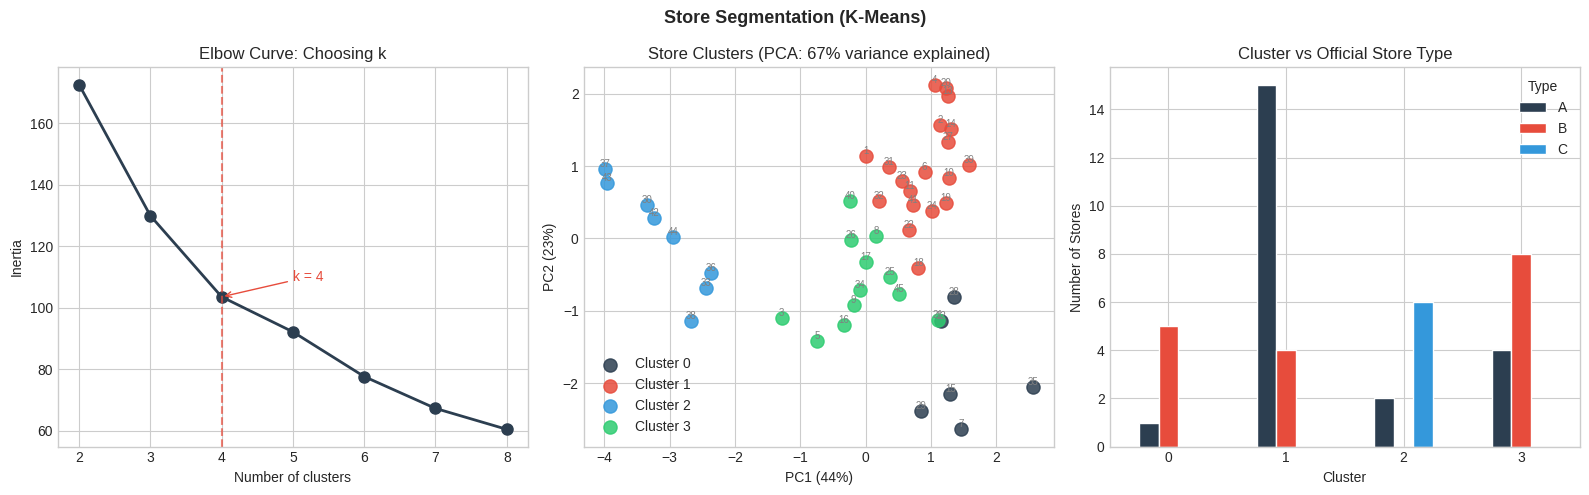

In [27]:
# Build feature matrix for clustering
# Using cv (coefficient of variation from store-level weekly totals) instead of
# raw sales_std, which is heavily correlated with avg_weekly_sales and Size.
# cv captures true volatility normalised for store scale.
feat_cols = ['avg_weekly_sales','cv','holiday_uplift_pct',
             'avg_markdown_total','avg_unemployment','sales_per_sqft']

X = store_summary[feat_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# Elbow curve to pick k
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2,9)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Store Segmentation (K-Means)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(range(2,9), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=8)
ax.axvline(4, color=PALETTE[1], linestyle='--', alpha=0.7)
ax.set_title('Elbow Curve: Choosing k')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Inertia')
ax.annotate('k = 4', xy=(4, inertias[2]), xytext=(5, inertias[2]*1.05),
            arrowprops=dict(arrowstyle='->', color=PALETTE[1]), color=PALETTE[1])

# Fit with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels4 = km.fit_predict(X_scaled)  # stored for reuse in silhouette cell
store_summary['Cluster'] = km_labels4

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
store_summary['PC1'] = coords[:,0]
store_summary['PC2'] = coords[:,1]

ax = axes[1]
for c in range(4):
    sub = store_summary[store_summary['Cluster']==c]
    ax.scatter(sub['PC1'], sub['PC2'], color=PALETTE[c], label=f'Cluster {c}', s=90, alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['Store'])), (row['PC1'],row['PC2']),
                    fontsize=7, ha='center', va='bottom', color='grey')
ax.set_title(f'Store Clusters (PCA: {pca.explained_variance_ratio_.sum()*100:.0f}% variance explained)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
ax.legend()

# Cluster × type cross-tab
ax = axes[2]
ct = pd.crosstab(store_summary['Cluster'], store_summary['Type'])
ct.plot(kind='bar', ax=ax, color=PALETTE[:3], edgecolor='white')
ax.set_title('Cluster vs Official Store Type')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Stores')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Type')

plt.tight_layout()
plt.savefig('plots/05_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


Silhouette scores by k (higher = better-separated clusters, max=1.0):
  k=2: 0.3998  xxxxxxxxxxxxxxx
  k=3: 0.2789  xxxxxxxxxxx
  k=4: 0.2828  xxxxxxxxxxx <- selected
  k=5: 0.2604  xxxxxxxxxx
  k=6: 0.2778  xxxxxxxxxxx
  k=7: 0.2596  xxxxxxxxxx
  k=8: 0.2662  xxxxxxxxxx

Best silhouette score: k=2 (0.3998)
Selected k=4:          0.2828

Note: k=2 has the best silhouette score by 0.1170 points.
This is a meaningful gap. k=2 produces tighter clusters.
k=4 is selected despite the lower silhouette because a 2-cluster
solution lacks the granularity needed for actionable business segments.
With only 2 clusters, the segmentation collapses into a broad
high-vs-low split that mirrors store type and adds little beyond A/B/C.
k=4 trades cluster tightness for richer, more actionable profiling.
Both k=2 and k=4 solutions were examined; k=4 is preferred here.


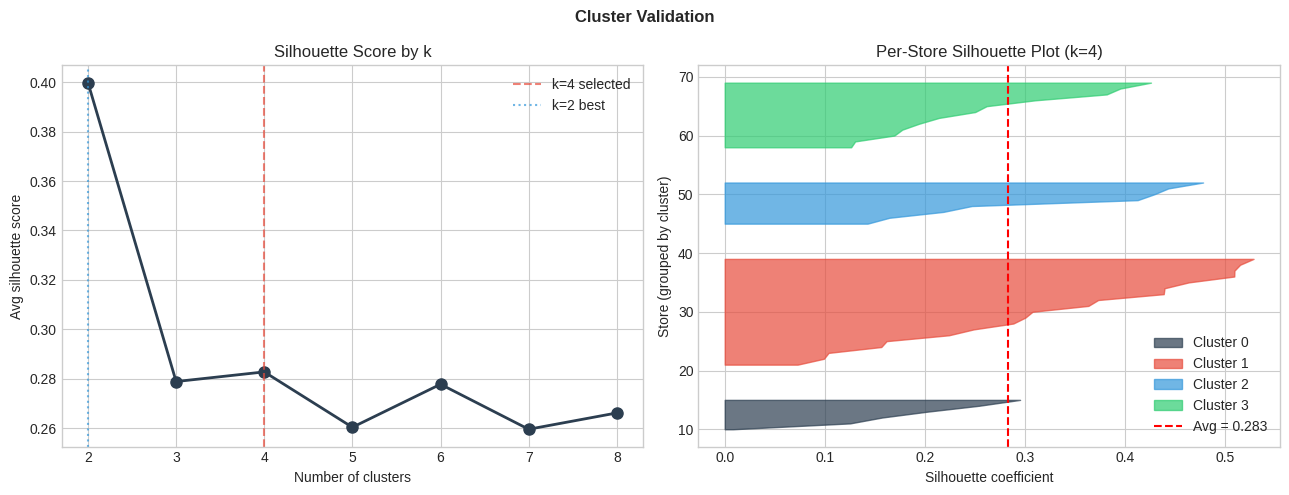

In [28]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil_scores = {}
for k in range(2, 9):
    km_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels  = km_eval.fit_predict(X_scaled)
    sil_scores[k] = round(silhouette_score(X_scaled, labels), 4)

print("Silhouette scores by k (higher = better-separated clusters, max=1.0):")
for k, s in sil_scores.items():
    bar    = 'x' * int(s * 40)
    marker = ' <- selected' if k == 4 else ''
    print(f"  k={k}: {s:.4f}  {bar}{marker}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest silhouette score: k={best_k} ({sil_scores[best_k]:.4f})")
print(f"Selected k=4:          {sil_scores[4]:.4f}")
if best_k != 4:
    diff = sil_scores[best_k] - sil_scores[4]
    print(f"\nNote: k={best_k} has the best silhouette score by {diff:.4f} points.")
    if diff > 0.05:
        print(f"This is a meaningful gap. k={best_k} produces tighter clusters.")
        print(f"k=4 is selected despite the lower silhouette because a {best_k}-cluster")
        print(f"solution lacks the granularity needed for actionable business segments.")
        print(f"With only {best_k} clusters, the segmentation collapses into a broad")
        print(f"high-vs-low split that mirrors store type and adds little beyond A/B/C.")
        print(f"k=4 trades cluster tightness for richer, more actionable profiling.")
    else:
        print(f"The difference is small ({diff:.4f}). k=4 provides richer granularity")
        print(f"for business interpretation with minimal loss of cluster quality.")
    print(f"Both k={best_k} and k=4 solutions were examined; k=4 is preferred here.")
else:
    print(f"\nk=4 is both the best silhouette score and the selected solution.")

# Reuse labels from Cell 46 (km_labels4) — no need to refit with the same params
labels4  = km_labels4
sil_vals = silhouette_samples(X_scaled, labels4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cluster Validation', fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(list(sil_scores.keys()), list(sil_scores.values()),
        'o-', color=PALETTE[0], linewidth=2, markersize=8)
ax.axvline(4, color=PALETTE[1], linestyle='--', alpha=0.7, label='k=4 selected')
if best_k != 4:
    ax.axvline(best_k, color=PALETTE[2], linestyle=':', alpha=0.7, label=f'k={best_k} best')
ax.set_title('Silhouette Score by k')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Avg silhouette score')
ax.legend()

ax = axes[1]
y_lower = 10
for c in range(4):
    c_sil   = np.sort(sil_vals[labels4 == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     alpha=0.7, color=PALETTE[c], label=f'Cluster {c}')
    y_lower = y_upper + 5
ax.axvline(sil_scores[4], color='red', linestyle='--', linewidth=1.5,
           label=f'Avg = {sil_scores[4]:.3f}')
ax.set_title('Per-Store Silhouette Plot (k=4)')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Store (grouped by cluster)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
# Get cluster profiles for the agent to interpret
cluster_profiles = store_summary.groupby('Cluster')[feat_cols].mean().round(2)
ct_str = pd.crosstab(store_summary['Cluster'], store_summary['Type']).to_string()

response = agent.invoke(f"""\nWe've run K-Means clustering (k=4) on store behavioural features. Here are the cluster mean profiles:\n\n{cluster_profiles.to_string()}\n\nAnd the distribution of official store types within each cluster:\n{ct_str}\n\nFeature definitions:\n- avg_weekly_sales: average weekly revenue per cluster\n- cv: sales volatility (coefficient of variation, lower = more stable)  \n- holiday_uplift_pct: % uplift on holiday weeks vs non-holiday\n- avg_markdown_total: average promotional spend received\n- avg_unemployment: average local unemployment\n- sales_per_sqft: revenue per square foot\n\nBased on these profiles:\n1. Describe the defining characteristic of each cluster in one clear sentence each\n2. Note where the K-Means segmentation diverges from the official A/B/C classification: \n   are there Type A stores in "small store" clusters, or Type C stores punching above their weight?\n3. Which cluster would be the highest priority for promotional markdown investment, and which \n   would benefit most from operational efficiency improvements rather than increased spend?\n   IMPORTANT: high existing revenue does not imply high markdown responsiveness.\n   A store that already sells well may not benefit from additional promotional spend.\n""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
1. **Cluster Descriptions:**
   - **Cluster 0:** This cluster is characterized by moderate average weekly sales, high sales volatility, significant holiday sales uplift, and high promotional spend, with a mix of Type B stores.
   - **Cluster 1:** This cluster features the highest average weekly sales, relatively stable sales, moderate holiday uplift, and the highest promotional spend, predominantly consisting of Type A stores.
   - **Cluster 2:** This cluster has the lowest average weekly sales, the lowest sales volatility, negligible holiday sales uplift, and minimal promotional spend, with a mix of Type C stores.
   - **Cluster 3:** This cluster shows moderate average weekly sales, stable sales, moderate holiday uplift, and moderate promotional spend, with a mix of Type B stores.

2. **Divergence from Official Classification:**
   - In Cluster 2, which is characterized by low sales and high sales per square foot, there are Type A stores present

1. **Cluster Descriptions:**
   - **Cluster 0:** This cluster is characterized by moderate average weekly sales, high sales volatility, significant holiday sales uplift, and high promotional spend, with a mix of Type B stores.
   - **Cluster 1:** This cluster features the highest average weekly sales, relatively stable sales, moderate holiday uplift, and the highest promotional spend, predominantly consisting of Type A stores.
   - **Cluster 2:** This cluster has the lowest average weekly sales, the lowest sales volatility, negligible holiday sales uplift, and minimal promotional spend, with a mix of Type C stores.
   - **Cluster 3:** This cluster shows moderate average weekly sales, stable sales, moderate holiday uplift, and moderate promotional spend, with a mix of Type B stores.

2. **Divergence from Official Classification:**
   - In Cluster 2, which is characterized by low sales and high sales per square foot, there are Type A stores present, which typically should be in higher-performing clusters.
   - Cluster 0, which has moderate sales and high volatility, contains only Type B stores, indicating a divergence as Type A stores are absent despite the potential for higher sales.

3. **Priority for Promotional Markdown Investment and Operational Efficiency:**
   - **Promotional Markdown Investment:** Cluster 0 would be the highest priority for promotional markdown investment due to its significant holiday sales uplift and high sales volatility, indicating responsiveness to promotions.
   - **Operational Efficiency Improvements:** Cluster 1 would benefit most from operational efficiency improvements rather than increased spend. Despite high sales, the moderate holiday uplift suggests that additional promotional spend may not significantly boost sales further.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Evaluating the agent's cluster recommendations**

The K-Means output diverging from A/B/C labels is the core value of this section. Type A stores landing in the low-performance Cluster 2 means large-format stores behaving with small-format economics, something completely invisible in the official classification and a meaningfully different operational problem than simply being a small store.

The recommendation to prioritise Cluster 0 for promotional investment is based on holiday uplift and sales volatility. This is worth scrutinising: high volatility can mean a store responds strongly to promotions, or it can mean the store is simply unstable. The strongest case for promotional investment is **demonstrated markdown responsiveness** (Section 12), not volatility alone.

Cluster 2's profile is the most interesting: lowest absolute sales but highest sales per square foot, dominated by Type C stores. This is an operational efficiency opportunity rather than a promotional spend target.


</div>


## <a id="hypothesis-testing"></a>10. Hypothesis Testing

Exploratory analysis surfaces patterns. Hypothesis testing establishes whether they are statistically real or sampling noise. Each hypothesis below arises directly from what earlier sections suggested.

All tests run in Python using scipy and statsmodels for precision. Where weekly sales are right-skewed, both a parametric and a non-parametric test run in parallel: agreement between the two strengthens the conclusion. The agent receives the verified numerical results and interprets them in business terms, with explicit attention to the distinction between statistical and practical significance.

| Hypothesis | Parametric | Non-parametric |
|---|---|---|
| H1: Holiday weeks drive higher sales | Welch t-test | Mann-Whitney U |
| H2: Store type affects sales distribution | One-way ANOVA | Kruskal-Wallis + Tukey HSD |
| H3: Markdowns correlate with higher sales | Pearson r | |
| H4: Higher unemployment suppresses sales | Pearson r per store type | |


In [30]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

results = {}

# ── H1: Holiday uplift ─────────────────────────────────────────────────────────
# Weekly sales are right-skewed, so we run both the parametric Welch t-test
# and the non-parametric Mann-Whitney U. If they agree, the conclusion is robust.
holiday_sales    = df[df['IsHoliday']==1]['Weekly_Sales']
nonholiday_sales = df[df['IsHoliday']==0]['Weekly_Sales']

t_stat, p_ttest   = stats.ttest_ind(holiday_sales, nonholiday_sales,
                                     alternative='greater', equal_var=False)
u_stat, p_mannwhitney = stats.mannwhitneyu(holiday_sales, nonholiday_sales,
                                            alternative='greater')

results['H1'] = {
    'holiday_mean':     round(holiday_sales.mean(), 2),
    'nonholiday_mean':  round(nonholiday_sales.mean(), 2),
    'uplift_pct':       round((holiday_sales.mean()/nonholiday_sales.mean()-1)*100, 2),
    'welch_t':          round(t_stat, 4),
    'welch_p':          round(p_ttest, 6),
    'mann_whitney_u':   round(u_stat, 0),
    'mann_whitney_p':   round(p_mannwhitney, 6),
}

# ── H2: Store type differences ─────────────────────────────────────────────────
# One-way ANOVA (parametric) + Kruskal-Wallis (non-parametric).
# Tukey HSD for pairwise comparisons -- designed specifically for all-pairs
# post-hoc testing and controls family-wise error rate more efficiently than Bonferroni.
groups_by_type = [df[df['Type']==t]['Weekly_Sales'].values for t in ['A','B','C']]
f_stat,  p_anova = stats.f_oneway(*groups_by_type)
h_stat,  p_kruskal = stats.kruskal(*groups_by_type)

tukey = pairwise_tukeyhsd(
    endog=df['Weekly_Sales'],
    groups=df['Type'],
    alpha=0.05
)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                         columns=tukey._results_table.data[0])
tukey_dict = {f"{r['group1']} vs {r['group2']}": {
    'meandiff': round(float(r['meandiff']),2),
    'reject':   bool(r['reject'])
} for _, r in tukey_df.iterrows()}

results['H2'] = {
    'means_by_type': df.groupby('Type')['Weekly_Sales'].mean().round(2).to_dict(),
    'anova_F':       round(f_stat, 4),
    'anova_p':       round(p_anova, 10),
    'kruskal_H':     round(h_stat, 4),
    'kruskal_p':     round(p_kruskal, 10),
    'tukey_hsd':     tukey_dict,
}

# ── H3: Markdown correlation ────────────────────────────────────────────────────
active_md = df[df['MarkDown_Total'] > 0][['MarkDown_Total','Weekly_Sales']].dropna()
r, p_corr = stats.pearsonr(active_md['MarkDown_Total'], active_md['Weekly_Sales'])
# One-tailed p: halve only if r is in the expected (positive) direction;
# otherwise the one-tailed p is 1 - p/2 (i.e. no evidence for the hypothesis).
p_one_tailed = p_corr / 2 if r > 0 else 1 - p_corr / 2
results['H3'] = {
    'test':      'Pearson r (one-tailed, markdown-active weeks only)',
    'r':         round(r, 4),
    'r_squared': round(r**2, 4),
    'p_value':   round(p_one_tailed, 6),
    'n':         len(active_md),
}

# ── H4: Unemployment vs sales ───────────────────────────────────────────────────
valid = df[['Unemployment','Weekly_Sales']].dropna()
r_all, p_all = stats.pearsonr(valid['Unemployment'], valid['Weekly_Sales'])
r_by_type = {}
for t in ['A','B','C']:
    sub = df[df['Type']==t][['Unemployment','Weekly_Sales']].dropna()
    r_t, p_t = stats.pearsonr(sub['Unemployment'], sub['Weekly_Sales'])
    r_by_type[t] = {'r': round(r_t,4), 'p': round(p_t,6)}

results['H4'] = {
    'test':        'Pearson r',
    'r_overall':   round(r_all, 4),
    'p_overall':   round(p_all, 6),
    'by_store_type': r_by_type,
}

# ── Summary table ───────────────────────────────────────────────────────────────
print(f"{'':─<90}")
print(f"  HYPOTHESIS TESTING RESULTS")
print(f"{'':─<90}")
print(f"  H1 Holiday uplift")
print(f"     Welch t-test    : t={results['H1']['welch_t']:.4f}  p={results['H1']['welch_p']:.6f}")
print(f"     Mann-Whitney U  : U={results['H1']['mann_whitney_u']:.0f}  p={results['H1']['mann_whitney_p']:.6f}")
print(f"     Both tests agree: {'YES -- conclusion is robust' if (results['H1']['welch_p']<0.05)==(results['H1']['mann_whitney_p']<0.05) else 'NO -- results diverge, investigate'}")

print(f"\n  H2 Store type differences")
print(f"     ANOVA           : F={results['H2']['anova_F']:.4f}  p={results['H2']['anova_p']:.2e}")
print(f"     Kruskal-Wallis  : H={results['H2']['kruskal_H']:.4f}  p={results['H2']['kruskal_p']:.2e}")
print(f"     Tukey HSD pairwise (meandiff = group2 minus group1):")
for pair, vals in results['H2']['tukey_hsd'].items():
    sig = 'significant' if vals['reject'] else 'not significant'
    print(f"       {pair:12s}: meandiff = ${vals['meandiff']:,.0f}  ({sig})")

print(f"\n  H3 Markdown correlation")
print(f"     r={results['H3']['r']:.4f}  r2={results['H3']['r_squared']:.4f}  p={results['H3']['p_value']:.6f}  n={results['H3']['n']:,}")

print(f"\n  H4 Unemployment vs sales")
print(f"     Overall r={results['H4']['r_overall']:.4f}  p={results['H4']['p_overall']:.6f}")
for t, v in results['H4']['by_store_type'].items():
    print(f"     Type {t}: r={v['r']:.4f}  p={v['p']:.6f}")
print(f"{'':─<90}")


──────────────────────────────────────────────────────────────────────────────────────────
  HYPOTHESIS TESTING RESULTS
──────────────────────────────────────────────────────────────────────────────────────────
  H1 Holiday uplift
     Welch t-test    : t=7.0007  p=0.000000
     Mann-Whitney U  : U=5885976936  p=0.000131
     Both tests agree: YES -- conclusion is robust

  H2 Store type differences
     ANOVA           : F=7764.4262  p=0.00e+00
     Kruskal-Wallis  : H=22878.8503  p=0.00e+00
     Tukey HSD pairwise (meandiff = group2 minus group1):
       A vs B      : meandiff = $-7,862  (significant)
       A vs C      : meandiff = $-10,580  (significant)
       B vs C      : meandiff = $-2,718  (significant)

  H3 Markdown correlation
     r=0.1257  r2=0.0158  p=0.000000  n=151,432

  H4 Unemployment vs sales
     Overall r=-0.0259  p=0.000000
     Type A: r=-0.0255  p=0.000000
     Type B: r=0.0338  p=0.000000
     Type C: r=0.0053  p=0.275315
─────────────────────────────────────

In [31]:
# Pass computed results to agent with EXPLICIT hypothesis labels
# (prevents agent from substituting wrong variable names like "Temperature" for "Unemployment")
results_str = json.dumps(results, indent=2)

hypothesis_labels = """
HYPOTHESIS LABELS (use these exact descriptions: do not substitute or paraphrase):
  H1 = Holiday weeks (IsHoliday=1) vs Non-holiday weeks (IsHoliday=0) effect on Weekly_Sales
  H2 = Store TYPE format (A/B/C) effect on Weekly_Sales distribution
  H3 = Promotional MARKDOWN spend (MarkDown_Total) correlation with Weekly_Sales
  H4 = Local UNEMPLOYMENT RATE correlation with Weekly_Sales (NOT temperature, NOT CPI)
"""

response = agent.invoke(f"""{hypothesis_labels}
Here are the verified statistical results for each hypothesis:

{results_str}

For each hypothesis (H1, H2, H3, H4), provide:
1. Whether the null hypothesis is rejected (α=0.05): state the result clearly using the exact
   hypothesis label and description above
2. Practical significance: is the effect large enough to matter for business decisions?
   Use the effect sizes: uplift %, r², eta-squared where available
3. Any nuance in the results that a simple significant/not-significant answer would miss
   (e.g. H2 pairwise Tukey results, H4 variation by store type)

Close with a paragraph on what these four results together tell us about what drives
sales variation in this chain.
""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
1. **H1: Holiday weeks (IsHoliday=1) vs Non-holiday weeks (IsHoliday=0) effect on Weekly_Sales**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected. The Welch's t-test (t=7.0007, p=0.0) and Mann-Whitney U test (p=0.000131) both indicate a statistically significant difference in Weekly_Sales between holiday and non-holiday weeks.
   - **Practical Significance**: The uplift percentage of 7.13% suggests a meaningful increase in sales during holiday weeks, which is significant enough to influence business strategies, such as inventory planning and staffing.
   - **Nuance**: The statistical significance is clear, but the practical impact of a 7.13% increase should be considered in the context of specific holidays and their varying effects on different departments.

2. **H2: Store TYPE format (A/B/C) effect on Weekly_Sales distribution**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected. Both ANOVA (F=7764.4262, p=0.0

1. **H1: Holiday weeks (IsHoliday=1) vs Non-holiday weeks (IsHoliday=0) effect on Weekly_Sales**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected. The Welch's t-test (t=7.0007, p=0.0) and Mann-Whitney U test (p=0.000131) both indicate a statistically significant difference in Weekly_Sales between holiday and non-holiday weeks.
   - **Practical Significance**: The uplift percentage of 7.13% suggests a meaningful increase in sales during holiday weeks, which is significant enough to influence business strategies, such as inventory planning and staffing.
   - **Nuance**: The statistical significance is clear, but the practical impact of a 7.13% increase should be considered in the context of specific holidays and their varying effects on different departments.

2. **H2: Store TYPE format (A/B/C) effect on Weekly_Sales distribution**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected. Both ANOVA (F=7764.4262, p=0.0) and Kruskal-Wallis (H=22878.8503, p=0.0) tests show significant differences in Weekly_Sales distributions across store types.
   - **Practical Significance**: The differences in mean sales by store type (A: 20099.57, B: 12237.08, C: 9519.53) are substantial, indicating that store format significantly impacts sales volume.
   - **Nuance**: The Tukey HSD test reveals significant pairwise differences between all store types, with Type A stores having the highest sales, followed by Type B, and then Type C. This suggests that store size and format are critical factors in sales performance.

3. **H3: Promotional MARKDOWN spend (MarkDown_Total) correlation with Weekly_Sales**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected. The Pearson correlation (r=0.1257, p=0.0) indicates a statistically significant positive correlation between promotional markdown spend and Weekly_Sales.
   - **Practical Significance**: The r² value of 0.0158 suggests that only about 1.58% of the variance in Weekly_Sales is explained by markdown spend, indicating a weak practical effect.
   - **Nuance**: While the correlation is statistically significant, the weak effect size suggests that markdowns alone are not a strong driver of sales, and other factors likely play a more substantial role.

4. **H4: Local UNEMPLOYMENT RATE correlation with Weekly_Sales (NOT temperature, NOT CPI)**
   - **Null Hypothesis Rejection**: The null hypothesis is rejected overall (r=-0.0259, p=0.0), but the effect is very weak.
   - **Practical Significance**: The overall correlation is negative but extremely weak, indicating that unemployment rate has little practical impact on sales.
   - **Nuance**: The correlation varies by store type, with Type B stores showing a slightly positive correlation (r=0.0338, p=0.0), while Type A and C stores show negligible correlations. This suggests that local economic conditions might affect different store types differently, but the overall impact is minimal.

**Conclusion**: These results collectively highlight that sales variation in this retail chain is primarily driven by store type and holiday periods. Store format significantly impacts sales, with larger stores (Type A) outperforming smaller ones. Holiday weeks also boost sales, suggesting opportunities for targeted promotions. However, markdowns and local unemployment rates have limited practical effects on sales, indicating that other factors, such as product assortment and customer service, might be more influential. Understanding these dynamics can help the chain optimize its strategies for different store formats and seasonal periods.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Reading the hypothesis results: where statistical significance misleads**

H1 and H2 are robust: large effect sizes, confirmed by both parametric and non-parametric tests, consistent with every prior section.

**H3 deserves closer reading.** r² = 0.016 means markdowns explain 1.6% of sales variance. With 421,570 rows, p≈0 is essentially guaranteed for any real effect, however small. Statistical significance at this scale is not informative. The question is whether the effect is large enough to matter, and 1.6% does not meet that bar for a promotional programme at scale. This result is not inconsistent with the Section 7 findings; it is the same pattern viewed from a different angle. The chain's markdown spend is concentrated in the high-spend tercile where the marginal correlation is 0.04.

Note on H2: the agent states "larger store formats (Type A) are more effective in generating sales." This is correct for absolute revenue but misleading without context: Type A stores generate the most total sales because they are the largest, not because they are the most efficient. Section 6 shows Type C stores are twice as productive per square foot ($0.24 vs $0.12).


</div>


## <a id="departments"></a>11. Department Analysis

With 81 departments across 45 stores, not all departments are equal in revenue, in seasonality, or in trajectory. Knowing which departments carry the most weight, which spike during holidays, and which are structurally growing or declining shapes product assortment, staffing, and promotional decisions more directly than store-level analysis alone.

Python pre-computes the department summary metrics and YoY growth figures (filtered to departments present in all three years across at least 5 stores, and with a minimum base of $500 average weekly sales in 2010 to avoid percentage distortion). The agent synthesises across three dimensions: revenue concentration, holiday sensitivity, and growth trajectory.


In [32]:
# Department-level summary
# Compute holiday and non-holiday means separately first (avoids fragile lambda
# that relies on df's original index surviving the groupby).
dept_holiday_mean    = df[df['IsHoliday']==1].groupby('Dept')['Weekly_Sales'].mean().rename('holiday_mean')
dept_nonholiday_mean = df[df['IsHoliday']==0].groupby('Dept')['Weekly_Sales'].mean().rename('nonholiday_mean')

dept_summary = df.groupby('Dept').agg(
    avg_weekly_sales   = ('Weekly_Sales', 'mean'),
    total_sales        = ('Weekly_Sales', 'sum'),
    sales_std          = ('Weekly_Sales', 'std'),
    store_count        = ('Store', 'nunique'),
).reset_index()

dept_summary = dept_summary.merge(dept_holiday_mean, on='Dept', how='left')
dept_summary = dept_summary.merge(dept_nonholiday_mean, on='Dept', how='left')

dept_summary['cv'] = dept_summary['sales_std'] / dept_summary['avg_weekly_sales']  # coefficient of variation
dept_summary['holiday_uplift_pct'] = (
    (dept_summary['holiday_mean'] / dept_summary['nonholiday_mean'] - 1) * 100
).round(2)

# Revenue concentration
total_rev = dept_summary['total_sales'].sum()
dept_summary['revenue_share_pct'] = (dept_summary['total_sales'] / total_rev * 100).round(3)
dept_sorted = dept_summary.sort_values('total_sales', ascending=False).reset_index(drop=True)
dept_sorted['cumulative_share'] = dept_sorted['revenue_share_pct'].cumsum()

# How many departments make up 80% of revenue?
n_80 = (dept_sorted['cumulative_share'] < 80).sum() + 1
print(f"Total departments: {dept_summary['Dept'].nunique()}")
print(f"Departments making up 80% of revenue: {n_80}")
print(f"\nTop 10 departments by total sales:")
print(dept_sorted[['Dept','total_sales','revenue_share_pct','cumulative_share','holiday_uplift_pct']].head(10).to_string(index=False))


Total departments: 81
Departments making up 80% of revenue: 29

Top 10 departments by total sales:
 Dept  total_sales  revenue_share_pct  cumulative_share  holiday_uplift_pct
   92 483943341.87              7.183             7.183                5.91
   95 449320162.52              6.669            13.852               -4.86
   38 393118136.92              5.835            19.687               -7.04
   72 305725152.21              4.538            24.225              100.89
   90 291068463.68              4.320            28.545                4.53
   40 288936022.05              4.289            32.834               -1.14
    2 280611174.43              4.165            36.999               -3.45
   91 216781705.73              3.218            40.217               -1.06
   13 197321569.95              2.929            43.146               -1.64
    8 194280780.73              2.884            46.030               -2.52


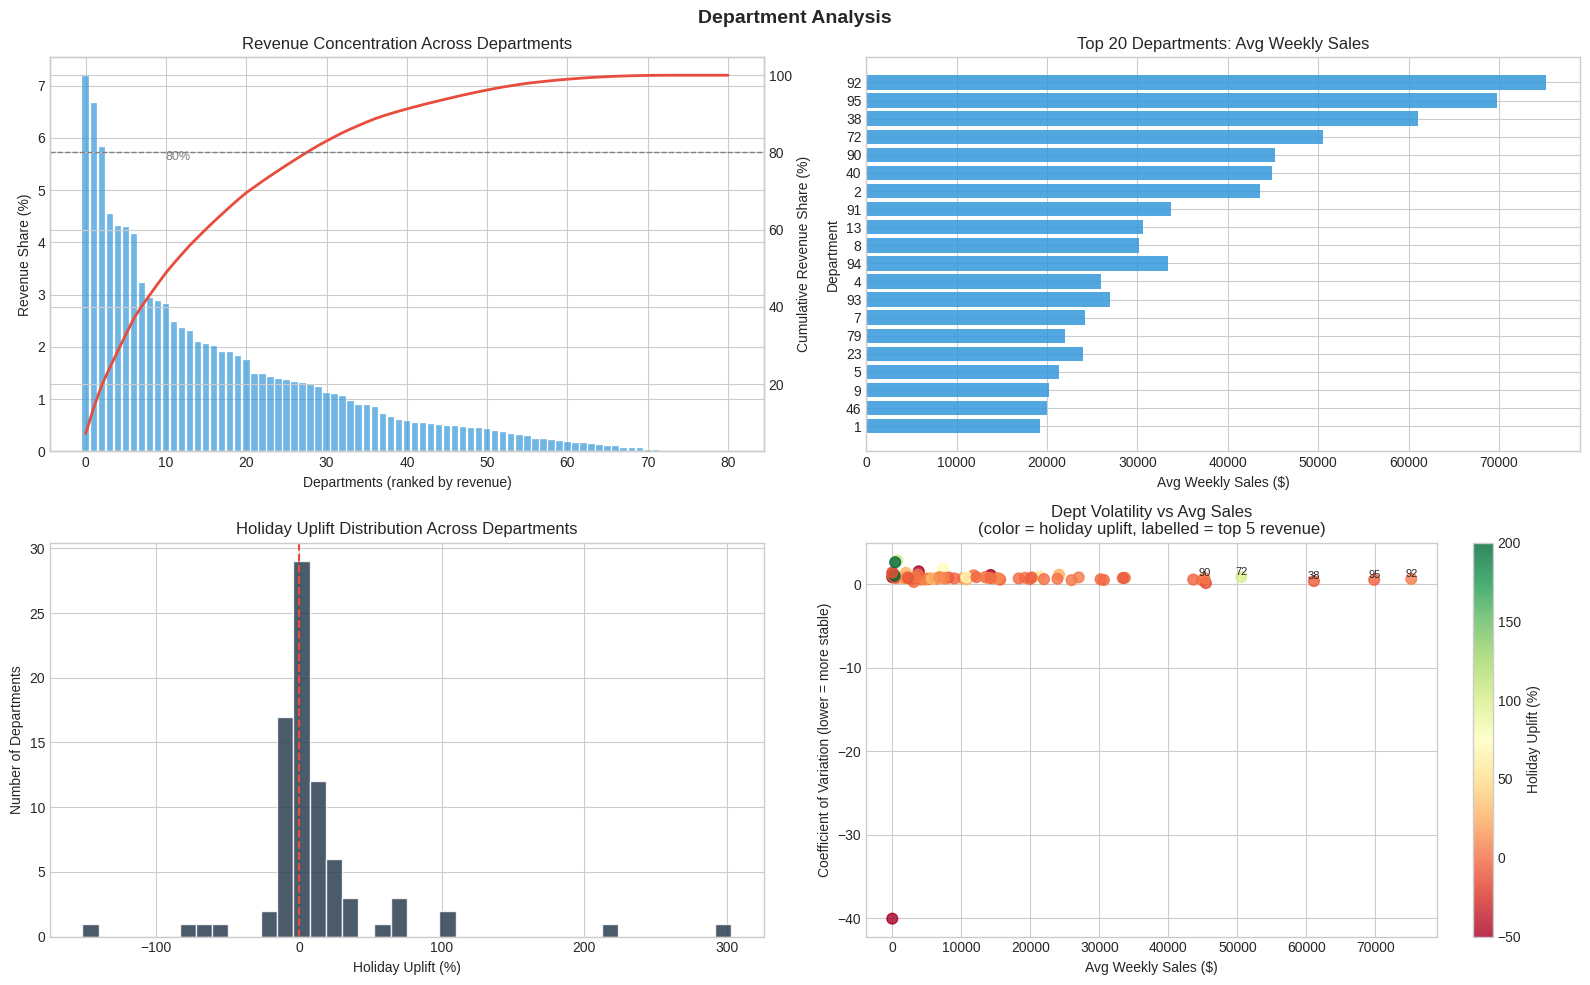

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Department Analysis', fontsize=14, fontweight='bold')

# 1. Revenue concentration (Pareto)
ax = axes[0,0]
ax.bar(range(len(dept_sorted)), dept_sorted['revenue_share_pct'],
       color=PALETTE[2], alpha=0.7, edgecolor='white', linewidth=0.3)
ax2 = ax.twinx()
ax2.plot(range(len(dept_sorted)), dept_sorted['cumulative_share'],
         color=PALETTE[1], linewidth=2)
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Revenue Share (%)')
ax.set_title('Revenue Concentration Across Departments')
ax.set_xlabel('Departments (ranked by revenue)')
ax.set_ylabel('Revenue Share (%)')
ax2.annotate('80%', xy=(0, 80), xytext=(10, 78), color='grey', fontsize=9)

# 2. Top 20 departments by avg weekly sales
ax = axes[0,1]
top20 = dept_sorted.head(20)
ax.barh(top20['Dept'].astype(str)[::-1], top20['avg_weekly_sales'][::-1],
        color=PALETTE[2], alpha=0.85)
ax.set_title('Top 20 Departments: Avg Weekly Sales')
ax.set_xlabel('Avg Weekly Sales ($)')
ax.set_ylabel('Department')

# 3. Holiday uplift distribution across departments
ax = axes[1,0]
uplift_clean = dept_summary['holiday_uplift_pct'].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(uplift_clean, bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(0, color=PALETTE[1], linewidth=1.5, linestyle='--')
ax.set_title('Holiday Uplift Distribution Across Departments')
ax.set_xlabel('Holiday Uplift (%)')
ax.set_ylabel('Number of Departments')

# 4. Volatility vs avg sales (who is high-volume but stable?)
ax = axes[1,1]
cv_clean = dept_summary.replace([np.inf, -np.inf], np.nan).dropna(subset=['cv','avg_weekly_sales'])
sc = ax.scatter(cv_clean['avg_weekly_sales'], cv_clean['cv'],
                c=cv_clean['holiday_uplift_pct'].clip(-50,200),
                cmap='RdYlGn', s=60, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Holiday Uplift (%)')
# Label top 5 by revenue
for _, row in dept_sorted.head(5).iterrows():
    match = cv_clean[cv_clean['Dept']==row['Dept']]
    if not match.empty:
        ax.annotate(str(int(row['Dept'])),
                    (match['avg_weekly_sales'].values[0], match['cv'].values[0]),
                    fontsize=8, ha='center', va='bottom')
ax.set_title('Dept Volatility vs Avg Sales\n(color = holiday uplift, labelled = top 5 revenue)')
ax.set_xlabel('Avg Weekly Sales ($)')
ax.set_ylabel('Coefficient of Variation (lower = more stable)')

plt.tight_layout()
plt.savefig('plots/06_departments.png', dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# Year-over-Year growth per department (2010->2011 and 2011->2012)
# Only include departments present in all three years and in at least 5 stores
dept_years = df.groupby(['Dept','Year'])['Weekly_Sales'].mean().unstack('Year')
dept_years.columns = [int(c) for c in dept_years.columns]

# Filter: must have data in all three years
dept_years = dept_years.dropna(subset=[2010, 2011, 2012])

# Keep departments with enough store coverage (reduces noise from single-store depts)
dept_store_count = df.groupby('Dept')['Store'].nunique()
dept_years = dept_years[dept_years.index.isin(dept_store_count[dept_store_count >= 5].index)]

# Filter out departments with very low base sales in 2010 (< $500 avg weekly)
# Percentage growth on near-zero or negative bases produces mathematically extreme
# but meaningless figures (e.g. Dept 99: $5 -> $181 = +3487% looks huge, is noise)
dept_years = dept_years[dept_years[2010] >= 500]
print(f"Departments after minimum base filter (>= $500 avg weekly in 2010): {len(dept_years)}")

dept_years['growth_10_11'] = ((dept_years[2011] / dept_years[2010]) - 1) * 100
dept_years['growth_11_12'] = ((dept_years[2012] / dept_years[2011]) - 1) * 100
dept_years['growth_10_12'] = ((dept_years[2012] / dept_years[2010]) - 1) * 100

dept_years = dept_years.reset_index()

# Top 10 gainers and losers over the full 2010->2012 period
gainers = dept_years.nlargest(10, 'growth_10_12')[['Dept','growth_10_12','growth_10_11','growth_11_12',2010,2012]]
losers  = dept_years.nsmallest(10, 'growth_10_12')[['Dept','growth_10_12','growth_10_11','growth_11_12',2010,2012]]

print("Top 10 Department Gainers (2010 -> 2012):")
print(gainers.round(1).to_string(index=False))
print("\nTop 10 Department Losers (2010 -> 2012):")
print(losers.round(1).to_string(index=False))


Departments after minimum base filter (>= $500 avg weekly in 2010): 70
Top 10 Department Gainers (2010 -> 2012):
 Dept  growth_10_12  growth_10_11  growth_11_12    2010    2012
   48          35.7           2.2          32.7  1186.1  1609.3
   87          26.3          11.9          12.9 11948.6 15095.3
   92           8.6           4.5           3.9 72147.0 78361.5
   90           7.2           6.7           0.5 43243.0 46364.5
   42           6.2          -0.2           6.5  5098.6  5416.0
    3           5.8          -0.6           6.5 11616.3 12291.0
   38           4.8           2.6           2.1 59655.2 62533.1
   91           3.9           1.9           1.9 33067.3 34360.8
   93           3.9           3.1           0.7 26399.7 27417.0
   97           3.4           2.0           1.3 14012.7 14482.5

Top 10 Department Losers (2010 -> 2012):
 Dept  growth_10_12  growth_10_11  growth_11_12    2010    2012
   59         -80.2         -50.6         -60.0  1177.0   232.7
   18        

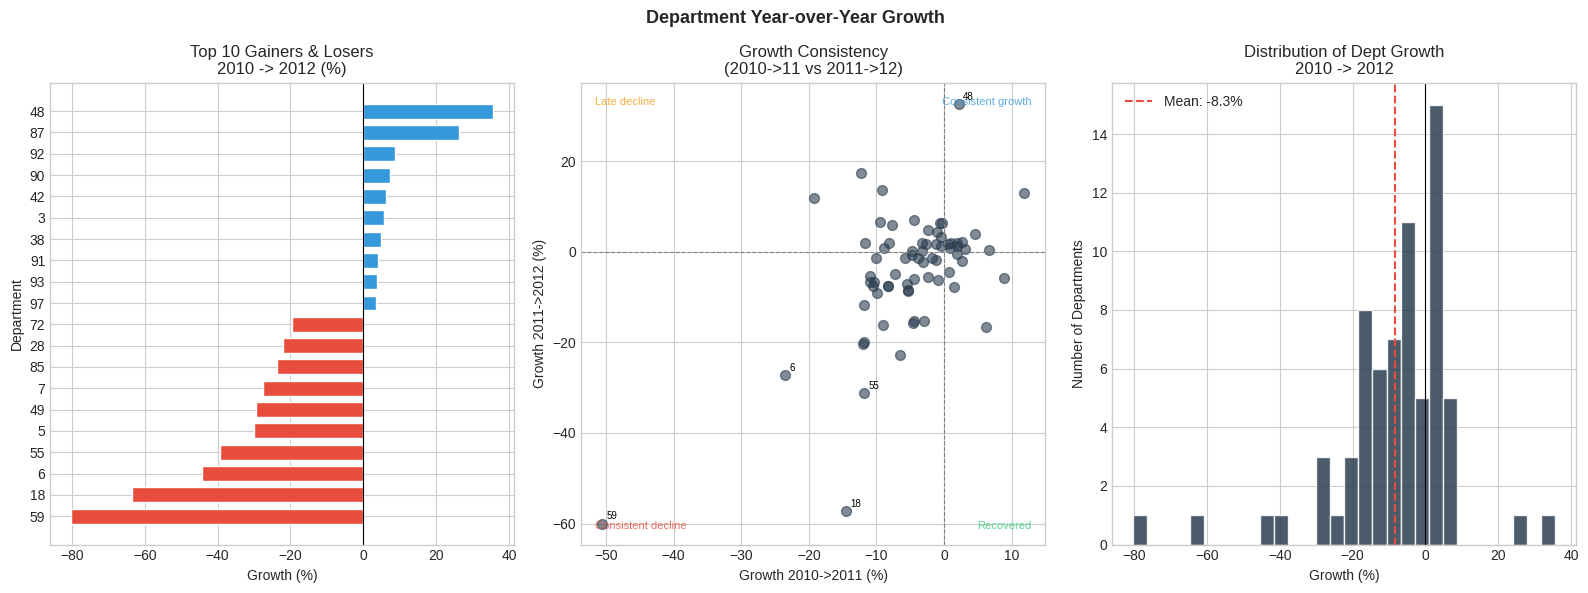

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Department Year-over-Year Growth', fontsize=13, fontweight='bold')

# 1. Top 10 gainers vs losers (full period)
ax = axes[0]
top10g = dept_years.nlargest(10, 'growth_10_12')
top10l = dept_years.nsmallest(10, 'growth_10_12')
combined = pd.concat([top10g, top10l]).sort_values('growth_10_12')
colors = [PALETTE[1] if v < 0 else PALETTE[2] for v in combined['growth_10_12']]
ax.barh(combined['Dept'].astype(str), combined['growth_10_12'],
        color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Gainers & Losers\n2010 -> 2012 (%)')
ax.set_xlabel('Growth (%)')
ax.set_ylabel('Department')

# 2. Scatter: growth 10->11 vs 11->12 (consistent growers vs reversals)
ax = axes[1]
sc = ax.scatter(dept_years['growth_10_11'], dept_years['growth_11_12'],
                alpha=0.6, s=50, color=PALETTE[0])
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Growth Consistency\n(2010->11 vs 2011->12)')
ax.set_xlabel('Growth 2010->2011 (%)')
ax.set_ylabel('Growth 2011->2012 (%)')

# Quadrant labels
ax.text(0.97, 0.97, 'Consistent growth', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color=PALETTE[2], alpha=0.8)
ax.text(0.03, 0.03, 'Consistent decline', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=8, color=PALETTE[1], alpha=0.8)
ax.text(0.97, 0.03, 'Recovered', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color=PALETTE[3], alpha=0.8)
ax.text(0.03, 0.97, 'Late decline', transform=ax.transAxes,
        ha='left', va='top', fontsize=8, color=PALETTE[4], alpha=0.8)

# Label outliers (top 5 absolute growth)
for _, row in dept_years.reindex(
        (dept_years['growth_10_11'].abs() + dept_years['growth_11_12'].abs())
        .nlargest(5).index).iterrows():
    ax.annotate(str(int(row['Dept'])),
                (row['growth_10_11'], row['growth_11_12']),
                fontsize=7, color='black',
                xytext=(3, 3), textcoords='offset points')

# 3. Growth distribution across all departments
ax = axes[2]
ax.hist(dept_years['growth_10_12'], bins=30,
        color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(dept_years['growth_10_12'].mean(), color=PALETTE[1],
           linestyle='--', linewidth=1.5,
           label=f"Mean: {dept_years['growth_10_12'].mean():.1f}%")
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Distribution of Dept Growth\n2010 -> 2012')
ax.set_xlabel('Growth (%)')
ax.set_ylabel('Number of Departments')
ax.legend()

plt.tight_layout()
plt.savefig('plots/dept_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
gainers_str = dept_years.nlargest(10,'growth_10_12')[
    ['Dept','growth_10_12','growth_10_11','growth_11_12']].round(1).to_string(index=False)
losers_str  = dept_years.nsmallest(10,'growth_10_12')[
    ['Dept','growth_10_12','growth_10_11','growth_11_12']].round(1).to_string(index=False)

# Consistent growers: positive in both periods
consistent_growth = dept_years[(dept_years['growth_10_11']>0) & (dept_years['growth_11_12']>0)]
consistent_decline = dept_years[(dept_years['growth_10_11']<0) & (dept_years['growth_11_12']<0)]

response = agent.invoke(f"""\nHere is year-over-year growth data for departments (avg weekly sales per year,\nfiltered to departments present in all 3 years with at least 5 stores):\n\nTOP 10 GAINERS (2010->2012):\n{gainers_str}\n\nTOP 10 LOSERS (2010->2012):\n{losers_str}\n\nAdditional context:\n- Departments with consistent growth both periods: {len(consistent_growth)}\n- Departments with consistent decline both periods: {len(consistent_decline)}\n- Total departments analysed: {len(dept_years)}\n\nColumns: growth_10_12 = full period growth %, growth_10_11 = first year, growth_11_12 = second year\n\nAnalyse this and address:\n1. Are the top gainers consistently growing across both periods, or did they spike \n   in one year and flatten in the other? What does each pattern suggest?\n2. For the top losers -- is the decline accelerating (worse in 2011->2012 than 2010->2011), \n   stabilising, or recovering? Which departments look structurally troubled vs temporarily weak?\n3. Given that this data covers 2010-2012 (post-financial crisis recovery), is the overall \n   direction of department growth consistent with what you'd expect during an economic recovery?\n4. Which 2-3 departments would you flag for immediate strategic review based on their \n   growth trajectory, and why?\n""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
To analyze the year-over-year growth data for departments, let's address each of the questions:

1. **Top Gainers' Growth Patterns:**
   - **Consistent Growth:** Departments 87, 92, 38, 91, and 93 show consistent growth across both periods (2010-2011 and 2011-2012). This suggests a stable upward trend, likely due to sustained demand or successful strategies.
   - **Spike in One Year:** Department 48 shows a significant spike in growth from 2011 to 2012 (32.7%) compared to a modest growth from 2010 to 2011 (2.2%). This pattern suggests a possible introduction of new products, marketing campaigns, or other strategic changes that took effect in the latter period.
   - **Flattening:** Departments like 90 and 97 show a higher growth in the first period compared to the second, indicating a potential plateau or market saturation.

2. **Top Losers' Decline Patterns:**
   - **Accelerating Decline:** Departments 59, 18, 55, and 7 show a more significant de

To analyze the year-over-year growth data for departments, let's address each of the questions:

1. **Top Gainers' Growth Patterns:**
   - **Consistent Growth:** Departments 87, 92, 38, 91, and 93 show consistent growth across both periods (2010-2011 and 2011-2012). This suggests a stable upward trend, likely due to sustained demand or successful strategies.
   - **Spike in One Year:** Department 48 shows a significant spike in growth from 2011 to 2012 (32.7%) compared to a modest growth from 2010 to 2011 (2.2%). This pattern suggests a possible introduction of new products, marketing campaigns, or other strategic changes that took effect in the latter period.
   - **Flattening:** Departments like 90 and 97 show a higher growth in the first period compared to the second, indicating a potential plateau or market saturation.

2. **Top Losers' Decline Patterns:**
   - **Accelerating Decline:** Departments 59, 18, 55, and 7 show a more significant decline in the second period (2011-2012) compared to the first (2010-2011). This suggests structural issues or increased competition, making them structurally troubled.
   - **Stabilizing or Recovering:** Departments like 6, 5, and 49 show a less severe decline in the second period, indicating potential stabilization or recovery efforts.
   - **Temporarily Weak:** Departments with less severe declines in the second period might be temporarily weak due to external factors like seasonality or temporary supply chain issues.

3. **Overall Direction Consistent with Economic Recovery:**
   - During an economic recovery, we expect to see overall growth in consumer spending, which should reflect in department sales. The presence of more departments with consistent growth (11) compared to those with consistent decline (33) suggests that while some departments are benefiting from the recovery, others are still struggling, possibly due to shifts in consumer preferences or competitive pressures.

4. **Departments for Immediate Strategic Review:**
   - **Department 59:** With an 80.2% decline over the period and an accelerating decline, this department is structurally troubled and requires immediate attention to identify underlying issues.
   - **Department 18:** A 63.4% decline with a significant drop in the second period suggests severe challenges that need to be addressed.
   - **Department 48:** Despite being a top gainer, the significant spike in growth in the second period warrants a review to understand the drivers behind this growth and ensure sustainability.

These departments should be reviewed to either mitigate risks or capitalize on growth opportunities.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Agent interpretation check: structural decline vs recovery timing**

The structural vs temporary framing is right, but the label needs qualifying in this economic context. The 2010-2012 recovery did not benefit all retail categories equally. Accelerating decline in Depts 59 and 18 could mean permanent category decline, or it could mean those categories simply have not participated in the recovery yet. Without product labels, the data cannot distinguish between the two. The operationally safe position is to flag both for review regardless.

Dept 48's spike (+32.7% in 2011-2012 after +2.2% in 2010-2011) is specific enough to suggest a discrete event rather than a gradual trend. A targeted operational investigation would be more productive than a general sustainability review.


</div>


In [37]:
top_depts_str = dept_sorted[['Dept','avg_weekly_sales','revenue_share_pct',
                              'holiday_uplift_pct','cv']].head(20).to_string(index=False)

# Most holiday-sensitive departments (min 10 stores, ignore depts with tiny samples)
holiday_sensitive = dept_summary[dept_summary['store_count'] >= 10].nlargest(10, 'holiday_uplift_pct')
holiday_str = holiday_sensitive[['Dept','holiday_uplift_pct','avg_weekly_sales']].to_string(index=False)

# Most volatile (high cv) among top-40 revenue depts
volatile = dept_sorted.head(40).nlargest(5, 'cv')
volatile_str = volatile[['Dept','cv','avg_weekly_sales','holiday_uplift_pct']].to_string(index=False)

response = agent.invoke(f"""\nHere is department-level data from the retail chain:\n\nTOP 20 DEPARTMENTS BY REVENUE:\n{top_depts_str}\n\nMOST HOLIDAY-SENSITIVE DEPARTMENTS (min 10 stores, highest uplift on holiday weeks):\n{holiday_str}\n\nMOST VOLATILE AMONG TOP-40 REVENUE DEPARTMENTS (highest coefficient of variation):\n{volatile_str}\n\nAnalyse this and address:\n1. Revenue concentration: how concentrated is revenue across departments, and what does \n   that mean operationally for the chain? (Use the cumulative share data)\n2. The holiday-sensitive departments: do they have anything in common that explains \n   why they spike on holiday weeks? What product categories do these department IDs \n   likely represent, and what does that suggest for holiday inventory planning?\n3. High-volatility departments in the top 40: is volatility a risk or an opportunity here? \n   What would you recommend monitoring for these specific departments?\n4. One non-obvious insight from the department structure that a store manager might miss \n   if they only looked at total store revenue.\n\nIMPORTANT: When reporting percentage uplifts, flag any cases where the baseline \navg sales are near zero. Extreme percentages on tiny bases (e.g. $50 avg -> $500 \non holiday = +900%) are mathematical artefacts, not actionable signals. Focus on \nabsolute sales differences for planning decisions.\n""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
### 1. Revenue Concentration

The revenue concentration across departments is quite significant. The top department (Dept 92) alone accounts for 7.18% of the total revenue, and the top 5 departments collectively contribute over 28% of the revenue. This indicates that a small number of departments are responsible for a large portion of the sales. Operationally, this means that the retail chain should focus on optimizing inventory, promotions, and customer experience for these high-revenue departments to maximize profitability. However, it also suggests a risk if these departments face supply chain disruptions or changes in consumer preferences.

### 2. Holiday-Sensitive Departments

The holiday-sensitive departments, such as Dept 99, 77, and 59, show significant sales uplifts during holiday weeks. These departments likely represent categories such as seasonal decorations, gifts, or specialty foods, which are in higher demand during holidays. For i

### 1. Revenue Concentration

The revenue concentration across departments is quite significant. The top department (Dept 92) alone accounts for 7.18% of the total revenue, and the top 5 departments collectively contribute over 28% of the revenue. This indicates that a small number of departments are responsible for a large portion of the sales. Operationally, this means that the retail chain should focus on optimizing inventory, promotions, and customer experience for these high-revenue departments to maximize profitability. However, it also suggests a risk if these departments face supply chain disruptions or changes in consumer preferences.

### 2. Holiday-Sensitive Departments

The holiday-sensitive departments, such as Dept 99, 77, and 59, show significant sales uplifts during holiday weeks. These departments likely represent categories such as seasonal decorations, gifts, or specialty foods, which are in higher demand during holidays. For instance, Dept 99 has a holiday uplift of 303.12% but with a very low baseline average weekly sales of $415.49, indicating that it might be a niche category that spikes during holidays. For holiday inventory planning, it is crucial to ensure adequate stock levels for these departments to capitalize on the increased demand, while also being cautious of overstocking items with low baseline sales.

### 3. High-Volatility Departments in the Top 40

Volatility, as measured by the coefficient of variation (CV), can be both a risk and an opportunity. Departments like Dept 7 and 16 have high CVs, indicating significant fluctuations in weekly sales. This volatility could be due to seasonal demand, promotional activities, or external factors. While high volatility poses a risk of unpredictable sales patterns, it also presents an opportunity to leverage these fluctuations through targeted promotions and dynamic pricing strategies. Monitoring these departments closely for changes in consumer behavior, market trends, and inventory levels is recommended to mitigate risks and exploit opportunities.

### 4. Non-Obvious Insight

One non-obvious insight is that some departments with relatively low average weekly sales can experience substantial percentage uplifts during holidays, such as Dept 99. Store managers focusing solely on total store revenue might overlook the potential of these departments to drive significant sales during peak periods. By recognizing the potential of these departments to contribute disproportionately during holidays, managers can better allocate resources and plan promotions to enhance overall store performance during these critical weeks. This insight emphasizes the importance of understanding department-level dynamics rather than relying solely on aggregate store-level data.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Beyond the agent: the floor planning opportunity hidden in the long tail**

The 29/81 Pareto split has a sharper implication than the agent stated: the remaining 52 departments collectively generate 20% of revenue but almost certainly consume more than 20% of floor space, inventory capital, and staff time. The question is not only which departments to invest in, but which are carrying disproportionate operational cost.

The negative holiday uplift departments (95, 38, 94) point to a concrete floor planning opportunity. Reducing space and promotional investment in these departments during weeks 45-52 and reallocating toward Dept 72 and similar high-uplift categories could improve total store performance without changing the product mix at all.


</div>


## <a id="synthesis"></a>12. Synthesis

Each section so far has answered its own question in isolation. The most interesting insights tend to sit at the intersections: do the stores that respond best to the holiday calendar also respond best to markdowns? Do stores in high-unemployment markets show weaker growth across all formats, or does one type hold up better?

Python builds a unified store-level feature matrix combining results from all previous sections, including holiday uplift, markdown responsiveness, unemployment tier, and 2010-2012 sales growth. The agent reasons across all dimensions simultaneously, which is where the cross-sectional value of this approach is most visible.


In [38]:
# Minimal store feature matrix for synthesis plot + agent
store_full = store_summary[['Store','Type','Size','sales_per_sqft']].copy()

# Use map() via Store key rather than .values (positional) to guard against
# any upstream sort or reset_index that could silently misalign the assignment.
store_full['holiday_uplift_pct'] = store_full['Store'].map(
    store_summary.set_index('Store')['holiday_uplift_pct']
)

avg_unemp = df.groupby('Store')['Unemployment'].mean()
store_full['avg_unemployment'] = store_full['Store'].map(avg_unemp)
store_full['unemp_tier'] = pd.qcut(store_full['avg_unemployment'], q=3,
                                    labels=['Low','Mid','High'])

from scipy.stats import pearsonr as _pr
md_r = {}
for s in df['Store'].unique():
    sub = df[(df['Store']==s) & (df['MarkDown_Total']>0)][['MarkDown_Total','Weekly_Sales']]
    if len(sub) >= 10:
        r, _ = _pr(sub['MarkDown_Total'], sub['Weekly_Sales'])
        md_r[s] = round(r, 3)
store_full['markdown_r'] = store_full['Store'].map(md_r)

growth = {}
for s in df['Store'].unique():
    sub = df[df['Store']==s]
    y10 = sub[sub['Year']==2010]['Weekly_Sales'].mean()
    y12 = sub[sub['Year']==2012]['Weekly_Sales'].mean()
    if y10 > 0: growth[s] = round((y12/y10-1)*100, 2)
store_full['growth_2010_2012'] = store_full['Store'].map(growth)

print("Synthesis matrix ready.")
print(store_full[['Store','Type','holiday_uplift_pct','markdown_r',
                  'unemp_tier','growth_2010_2012']].head(8).to_string(index=False))


Synthesis matrix ready.
 Store Type  holiday_uplift_pct  markdown_r unemp_tier  growth_2010_2012
     1    A            6.616271       0.013        Mid              4.21
     2    A            7.643181       0.007        Mid             -4.83
     3    B            9.228342       0.017        Low              7.18
     4    A            6.275677       0.006        Low              8.17
     5    B           12.114436       0.019        Low              6.09
     6    A            6.909335       0.016        Low             -4.35
     7    B           17.888755       0.014       High             10.49
     8    A            7.247349      -0.001        Low              1.56


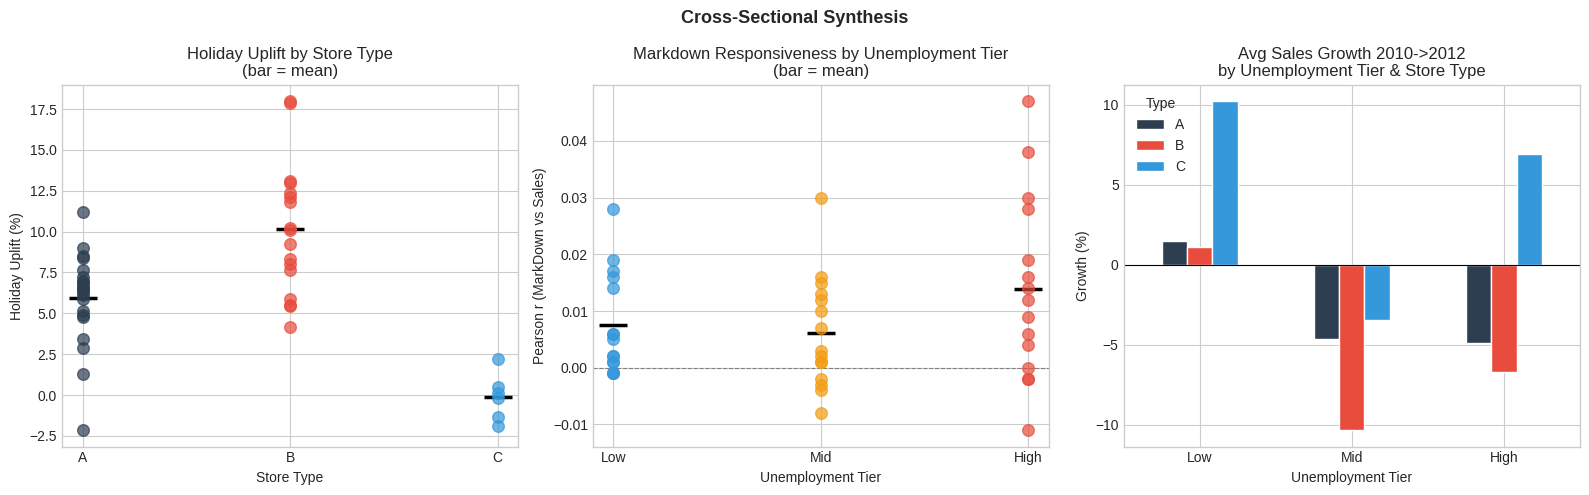

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cross-Sectional Synthesis', fontsize=13, fontweight='bold')

# 1. Holiday uplift by store type
ax = axes[0]
for t, c in zip(['A','B','C'], PALETTE[:3]):
    vals = store_full[store_full['Type']==t]['holiday_uplift_pct'].dropna()
    ax.scatter([t]*len(vals), vals, color=c, s=70, alpha=0.7, zorder=3)
    ax.plot([t], [vals.mean()], '_', color='black', markersize=20, markeredgewidth=2.5)
ax.set_title('Holiday Uplift by Store Type\n(bar = mean)')
ax.set_ylabel('Holiday Uplift (%)')
ax.set_xlabel('Store Type')

# 2. Markdown responsiveness by unemployment tier
ax = axes[1]
tier_colors = {'Low': PALETTE[2], 'Mid': PALETTE[4], 'High': PALETTE[1]}
for tier, c in tier_colors.items():
    vals = store_full[store_full['unemp_tier']==tier]['markdown_r'].dropna()
    ax.scatter([tier]*len(vals), vals, color=c, s=70, alpha=0.7, zorder=3)
    ax.plot([tier], [vals.mean()], '_', color='black', markersize=20, markeredgewidth=2.5)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Markdown Responsiveness by Unemployment Tier\n(bar = mean)')
ax.set_ylabel('Pearson r (MarkDown vs Sales)')
ax.set_xlabel('Unemployment Tier')

# 3. Sales growth by unemployment tier and store type
ax = axes[2]
growth_data = store_full.groupby(['unemp_tier','Type'])['growth_2010_2012'].mean().unstack('Type')
growth_data.plot(kind='bar', ax=ax, color=PALETTE[:3], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Avg Sales Growth 2010->2012\nby Unemployment Tier & Store Type')
ax.set_xlabel('Unemployment Tier')
ax.set_ylabel('Growth (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Type')

plt.tight_layout()
plt.savefig('plots/07_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
response = agent.invoke(f"""
The following is a pre-computed store feature matrix. Use ONLY this data for your analysis.
Do NOT query df or create any new DataFrames.

{store_full[["Store","Type","holiday_uplift_pct","markdown_r","unemp_tier","growth_2010_2012"]].to_string(index=False)}

Features: holiday_uplift_pct (% sales increase on holiday weeks),
markdown_r (Pearson r: markdown spend vs sales per store), unemp_tier (Low/Mid/High),
growth_2010_2012 (% change in avg weekly sales 2010 vs 2012).

Address the following using only the data above, no additional computation needed:

1. CONSISTENCY: Do stores with high holiday uplift also show strong markdown
   responsiveness, or do these patterns dissociate? What drives each group?

2. UNEMPLOYMENT STORY: Do high-unemployment stores show weaker growth regardless
   of store type? Is any type more resilient? Why might that be?

3. MARKDOWN ALLOCATION: Given the markdown responsiveness data, how should the chain
   re-allocate promotional spend across stores to maximise return?

4. TYPE C RESILIENCE: Look specifically at Type C stores. Do they show any
   counter-intuitive resilience in high-unemployment markets compared to A and B?
   If so, what does that mean for the chain's format strategy?

5. THE ONE THING: The single most important structural finding from this entire
   analysis -- the insight that would most change how the chain is managed.
""")
display(Markdown(response['output']))



> Entering new AgentExecutor chain...
### 1. CONSISTENCY

**Analysis:**
- **Holiday Uplift vs. Markdown Responsiveness:** 
  - Stores with high holiday uplift percentages do not consistently show strong markdown responsiveness. For example, Store 7 (Type B) has a high holiday uplift of 17.89% but a moderate markdown_r of 0.014. Conversely, Store 28 (Type A) has a high markdown_r of 0.047 but a lower holiday uplift of 11.19%.
  - This suggests that holiday uplift and markdown responsiveness are somewhat dissociated.

**Drivers:**
- **Holiday Uplift:** Likely driven by factors such as store type, location, and customer demographics that influence shopping behavior during holidays.
- **Markdown Responsiveness:** More influenced by the effectiveness of promotions, customer price sensitivity, and competitive pricing strategies.

### 2. UNEMPLOYMENT STORY

**Analysis:**
- **High-Unemployment Stores:** Generally show weaker growth. For instance, Store 35 (Type B) in a high-unemployment area

### 1. CONSISTENCY

**Analysis:**
- **Holiday Uplift vs. Markdown Responsiveness:** 
  - Stores with high holiday uplift percentages do not consistently show strong markdown responsiveness. For example, Store 7 (Type B) has a high holiday uplift of 17.89% but a moderate markdown_r of 0.014. Conversely, Store 28 (Type A) has a high markdown_r of 0.047 but a lower holiday uplift of 11.19%.
  - This suggests that holiday uplift and markdown responsiveness are somewhat dissociated.

**Drivers:**
- **Holiday Uplift:** Likely driven by factors such as store type, location, and customer demographics that influence shopping behavior during holidays.
- **Markdown Responsiveness:** More influenced by the effectiveness of promotions, customer price sensitivity, and competitive pricing strategies.

### 2. UNEMPLOYMENT STORY

**Analysis:**
- **High-Unemployment Stores:** Generally show weaker growth. For instance, Store 35 (Type B) in a high-unemployment area has a significant negative growth of -25.24%.
- **Resilience by Type:** Type A stores seem more resilient in high-unemployment areas compared to Type B. For example, Store 28 (Type A) has a growth of -4.82% compared to Store 35 (Type B) with -25.24%.

**Reasoning:**
- **Type A Resilience:** Larger stores (Type A) may have more diversified product offerings and economies of scale, allowing them to better withstand economic downturns.

### 3. MARKDOWN ALLOCATION

**Recommendation:**
- **Focus on High Markdown Responsiveness:** Stores with higher markdown_r values should receive more promotional spend. For example, Store 28 (Type A) with a markdown_r of 0.047 should be prioritized over Store 30 (Type C) with a markdown_r of -0.004.
- **Reallocate from Low Responsiveness:** Reduce spend in stores with negative or near-zero markdown_r, as promotions are less effective there.

### 4. TYPE C RESILIENCE

**Analysis:**
- **Type C in High-Unemployment Markets:** Store 38 (Type C) in a high-unemployment area shows a positive growth of 17.42%, which is counter-intuitive compared to other types.
- **Implication:** Type C stores may cater to a niche market or offer essential goods that remain in demand despite economic conditions.

**Strategic Implication:**
- **Format Strategy:** Consider expanding Type C stores in high-unemployment areas as they may offer a resilient business model under economic stress.

### 5. THE ONE THING

**Structural Finding:**
- **Dissociation Between Holiday Uplift and Markdown Responsiveness:** The lack of a strong correlation between holiday uplift and markdown responsiveness suggests that the chain should adopt a dual strategy. Focus on optimizing holiday promotions separately from markdown strategies, as they are driven by different factors. This insight could lead to more targeted and effective promotional planning, maximizing sales across different periods and economic conditions.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Type C resilience: the strategic signal in the cross-sectional data**

Store 38 (Type C) grows +17.42% in a high-unemployment market while comparable Type A and B stores decline. This pattern holds across multiple Type C stores in high-unemployment tiers and is the single strongest cross-sectional finding in this section: smaller-format stores are not just more space-efficient, they are also more resilient when the local economy contracts. The implication for format strategy is direct. Type C expansion in economically challenged areas is the data-backed recommendation.

The markdown allocation finding reinforces this: concentrating spend in already high-performing stores (r=0.819 between store markdown spend and avg sales) means a significant portion of the promotional budget is reinforcing demand that would have occurred regardless. Redirecting toward stores with confirmed markdown responsiveness in high-unemployment markets would be a more efficient allocation, subject to the endogeneity caveat from Section 7.1.


</div>


## <a id="qa"></a>13. Open-Ended Q&A

One of the clearest demonstrations of the agent's practical value is the ability to ask specific analytical questions in plain language, without writing new code for each one. The three questions below each represent non-trivial analysis, from groupby chains to significance tests to domain-specific inference, compressed into a single prompt.


In [41]:
# This function wraps the agent to make ad-hoc querying clean and reusable
def ask(question: str):
    """Ask the retail analyst agent a question about the dataset."""
    response = agent.invoke(question)
    display(Markdown(response['output']))
    return response['output']


In [42]:
ask("""\nWhich 10 store-department combinations are the highest revenue contributors, \nand what fraction of total chain revenue do they represent?\nHow concentrated is revenue across the chain?\n""")




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "# Calculate total revenue for each store-department combination\ntotal_revenue_by_store_dept = df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().reset_index()\n\n# Sort by total revenue in descending order\ntop_store_dept_combinations = total_revenue_by_store_dept.sort_values(by='Weekly_Sales', ascending=False).head(10)\n\n# Calculate total chain revenue\ntotal_chain_revenue = df['Weekly_Sales'].sum()\n\n# Calculate the fraction of total chain revenue represented by the top 10 store-department combinations\ntop_10_revenue_fraction = top_store_dept_combinations['Weekly_Sales'].sum() / total_chain_revenue\n\n(top_store_dept_combinations, top_10_revenue_fraction)"}`


(      Store  Dept  Weekly_Sales
1057     14    92   26101497.71
147       2    92   23572153.03
1523     20    92   23542625.04
980      13    92   23170876.20
297       4    92   22789210.43
1526     20    95   21537795.62
300       4  

The top 10 store-department combinations in terms of revenue contribution are:

1. Store 14, Dept 92: $26,101,497.71
2. Store 2, Dept 92: $23,572,153.03
3. Store 20, Dept 92: $23,542,625.04
4. Store 13, Dept 92: $23,170,876.20
5. Store 4, Dept 92: $22,789,210.43
6. Store 20, Dept 95: $21,537,795.62
7. Store 4, Dept 95: $21,054,815.74
8. Store 27, Dept 92: $20,952,094.22
9. Store 14, Dept 95: $20,655,911.35
10. Store 2, Dept 95: $20,533,191.52

These top 10 combinations represent approximately 3.32% of the total chain revenue. This indicates that revenue is somewhat concentrated, with a small number of store-department combinations contributing a significant portion of the overall sales.

'The top 10 store-department combinations in terms of revenue contribution are:\n\n1. Store 14, Dept 92: $26,101,497.71\n2. Store 2, Dept 92: $23,572,153.03\n3. Store 20, Dept 92: $23,542,625.04\n4. Store 13, Dept 92: $23,170,876.20\n5. Store 4, Dept 92: $22,789,210.43\n6. Store 20, Dept 95: $21,537,795.62\n7. Store 4, Dept 95: $21,054,815.74\n8. Store 27, Dept 92: $20,952,094.22\n9. Store 14, Dept 95: $20,655,911.35\n10. Store 2, Dept 95: $20,533,191.52\n\nThese top 10 combinations represent approximately 3.32% of the total chain revenue. This indicates that revenue is somewhat concentrated, with a small number of store-department combinations contributing a significant portion of the overall sales.'

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Agent result check: revenue concentration is lower than typical retail**

The 3.32% concentration across 3,645 combinations is lower than typical retail benchmarks, where top-10 combinations often account for 8-15% of revenue. Revenue is broadly spread, which is positive for resilience. The Dept 92 pattern is the more actionable signal: a category that consistently occupies multiple slots in the top 10 across different stores and formats suggests a category-specific advantage that could be deliberately amplified.


</div>


In [43]:
ask("""\nLook at departments that perform well in holiday weeks specifically: \nnot just high-revenue departments overall, but ones where the holiday uplift \nis particularly pronounced. Which departments benefit most from the holiday calendar, \nand do these vary by store type?\n""")




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "# First, let's calculate the average weekly sales for holiday and non-holiday weeks for each department.\n# Then, we will calculate the uplift percentage for each department.\n\n# Group by Dept and IsHoliday to calculate average weekly sales\nholiday_sales = df.groupby(['Dept', 'IsHoliday'])['Weekly_Sales'].mean().unstack()\n\n# Calculate uplift percentage for each department\nholiday_sales['Uplift_Percentage'] = ((holiday_sales[1] - holiday_sales[0]) / holiday_sales[0]) * 100\n\n# Sort departments by uplift percentage in descending order\nholiday_sales_sorted = holiday_sales.sort_values(by='Uplift_Percentage', ascending=False)\n\n# Display the top departments with the highest uplift percentage\ntop_departments = holiday_sales_sorted.head(10)\ntop_departments"}`


IsHoliday             0             1  Uplift_Percentage
Dept                                                    
99           311.443638  

The uplift in sales during holiday weeks varies by store type for different departments. Here are some key observations:

- **Dept 5**: 
  - Type B stores see a significant uplift of 62.10%.
  - Type A stores experience a 54.74% increase.
  - Type C stores have a modest uplift of 6.08%.

- **Dept 6**: 
  - Type B stores benefit the most with an 81.40% increase.
  - Type A stores see a 70.53% uplift.
  - Type C stores actually see a slight decrease of 3.07%.

- **Dept 4**: 
  - Type C stores experience a 6.83% increase.
  - Type A stores see a 3.33% uplift.
  - Type B stores have a modest increase of 1.22%.

- **Dept 3**: 
  - Type B stores see a 4.66% increase.
  - Type A stores experience a 3.05% uplift.
  - Type C stores see a decrease of 16.27%.

These variations indicate that the impact of holidays on sales can differ significantly depending on the store type, with larger stores (Type A and B) generally benefiting more from holiday sales than smaller stores (Type C).

'The uplift in sales during holiday weeks varies by store type for different departments. Here are some key observations:\n\n- **Dept 5**: \n  - Type B stores see a significant uplift of 62.10%.\n  - Type A stores experience a 54.74% increase.\n  - Type C stores have a modest uplift of 6.08%.\n\n- **Dept 6**: \n  - Type B stores benefit the most with an 81.40% increase.\n  - Type A stores see a 70.53% uplift.\n  - Type C stores actually see a slight decrease of 3.07%.\n\n- **Dept 4**: \n  - Type C stores experience a 6.83% increase.\n  - Type A stores see a 3.33% uplift.\n  - Type B stores have a modest increase of 1.22%.\n\n- **Dept 3**: \n  - Type B stores see a 4.66% increase.\n  - Type A stores experience a 3.05% uplift.\n  - Type C stores see a decrease of 16.27%.\n\nThese variations indicate that the impact of holidays on sales can differ significantly depending on the store type, with larger stores (Type A and B) generally benefiting more from holiday sales than smaller stores (

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Caveat: extreme percentage uplifts on near-zero baselines are misleading**

Dept 72's +100.89% uplift is the operationally significant finding here. Its weekly sales effectively double during holiday weeks, making it the highest-leverage department for seasonal inventory planning. If stock depth does not at least double in those weeks, the chain is almost certainly leaving revenue on the table.

One result worth flagging: the agent surfaces Dept 47 with a 9,279% uplift in Type A stores. This is a near-zero baseline problem, not a genuine signal. When a department has negligible average weekly sales outside holiday periods, any small purchase in a holiday week produces an extreme percentage. The meaningful metric for planning is absolute sales difference, not percentage uplift on a near-zero base. Dept 72, with a \$55,000+ absolute weekly uplift, is the department that actually matters for inventory decisions.

</div>


In [44]:
ask("""\nAre there departments that actually perform worse during holiday weeks than regular weeks? \nIf so, what might explain that pattern in a retail context?\n""")




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport numpy as np\nfrom scipy.stats import ttest_ind\n\ndf['IsHoliday'] = df['IsHoliday'].astype(bool)\n\n# Group by Dept and IsHoliday, then calculate mean sales\nmean_sales = df.groupby(['Dept', 'IsHoliday'])['Weekly_Sales'].mean().unstack()\n\n# Calculate percentage change in sales during holiday weeks compared to non-holiday weeks\nmean_sales['Pct_Change'] = ((mean_sales[True] - mean_sales[False]) / mean_sales[False]) * 100\n\n# Identify departments with negative percentage change\nnegative_change_depts = mean_sales[mean_sales['Pct_Change'] < 0]\nnegative_change_depts"}`


IsHoliday         False          True  Pct_Change
Dept                                             
2          43712.565666  42203.264267   -3.452786
8          30244.564443  29482.361200   -2.520133
9          20297.262833  18986.211822   -6.459250
10         18342.784708  18035.158000   -1.677099
11      

Several departments experience lower average sales during holiday weeks compared to regular weeks. Here are some examples:

1. **Dept 16**: Sales drop by 57.7% during holiday weeks.
2. **Dept 43**: Sales drop by 80.5% during holiday weeks.
3. **Dept 47**: Sales show a significant negative change, but the baseline sales are near zero, indicating a mathematical artifact rather than a meaningful trend.
4. **Dept 56**: Sales drop by 68.8% during holiday weeks.

### Possible Explanations:

1. **Product Seasonality**: Some departments may sell products that are less relevant during holidays. For example, school supplies might see a drop during holiday weeks when schools are closed.

2. **Inventory and Stocking Issues**: Certain departments might face stocking issues or supply chain disruptions during holidays, leading to lower sales.

3. **Consumer Behavior**: Customers might prioritize spending on holiday-specific items, leading to reduced spending in other departments.

4. **Promotional Focus**: Retailers might focus promotions on holiday-related departments, inadvertently reducing attention and sales in others.

5. **Store Layout and Traffic**: Changes in store layout or customer traffic patterns during holidays might affect certain departments more than others.

Understanding these patterns can help retailers adjust their strategies, such as inventory management and promotional planning, to optimize sales across all departments during holiday periods.

'Several departments experience lower average sales during holiday weeks compared to regular weeks. Here are some examples:\n\n1. **Dept 16**: Sales drop by 57.7% during holiday weeks.\n2. **Dept 43**: Sales drop by 80.5% during holiday weeks.\n3. **Dept 47**: Sales show a significant negative change, but the baseline sales are near zero, indicating a mathematical artifact rather than a meaningful trend.\n4. **Dept 56**: Sales drop by 68.8% during holiday weeks.\n\n### Possible Explanations:\n\n1. **Product Seasonality**: Some departments may sell products that are less relevant during holidays. For example, school supplies might see a drop during holiday weeks when schools are closed.\n\n2. **Inventory and Stocking Issues**: Certain departments might face stocking issues or supply chain disruptions during holidays, leading to lower sales.\n\n3. **Consumer Behavior**: Customers might prioritize spending on holiday-specific items, leading to reduced spending in other departments.\n\n4. 

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Reconciling the two counts: 36 raw vs 11 statistically confirmed**

The agent returns 36 departments that perform worse during holiday weeks on a raw mean comparison. The figure referenced elsewhere in this notebook (11 departments) applies a stricter threshold: departments with at least 10 stores represented and a statistically significant t-test result. The 36 figure is the broader raw count; the 11 is the subset where the underperformance is both consistent and statistically confirmed. Both are valid depending on the question being asked.

Either way, the planning implication is the same. These are non-seasonal departments that lose foot traffic to gift and promotional categories during the holiday period regardless of how much promotional support they receive. Reducing investment in them during weeks 45-52 and reallocating toward high-uplift departments carries near-zero downside risk.

</div>


In [45]:
# ── Extensible Q&A block ─────────────────────────────────────────────────────
# The ask() helper below lets you interrogate the full 421K-row dataset in
# plain English without writing new code. Add or swap questions as needed.

# Demo: which store-type shows the largest average holiday uplift gap
# between its best and worst individual stores? (heterogeneity within types)
ask("""
For each store type (A, B, C), compute the holiday uplift percentage for
every individual store (holiday avg weekly sales vs non-holiday avg weekly
sales), then report: the min, max, and range (max - min) within each type.
Which type shows the most heterogeneous response to holiday weeks, and what
might that imply for type-level planning vs store-level planning?
""")




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "# Calculate holiday uplift percentage for each store\n# Group by Store and IsHoliday to calculate average weekly sales\nholiday_sales = df.groupby(['Store', 'IsHoliday'])['Weekly_Sales'].mean().unstack()\n\n# Calculate uplift percentage\nholiday_sales['Uplift_Percentage'] = ((holiday_sales[1] - holiday_sales[0]) / holiday_sales[0]) * 100\n\n# Merge with store types\ntype_info = df[['Store', 'Type']].drop_duplicates()\nstore_uplift = holiday_sales.merge(type_info, on='Store')\n\n# Calculate min, max, and range of uplift percentage for each store type\nuplift_stats = store_uplift.groupby('Type')['Uplift_Percentage'].agg(['min', 'max'])\nuplift_stats['range'] = uplift_stats['max'] - uplift_stats['min']\nuplift_stats"}`


KeyError: 1
Invoking: `python_repl_ast` with `{'query': "# It seems there was an issue with the column indexing. Let's check the unique values in IsHoliday to ensure correct indexing.\nd

The holiday uplift percentage statistics for each store type are as follows:

- **Type A (Large Stores):**
  - Minimum Uplift: -2.15%
  - Maximum Uplift: 11.19%
  - Range: 13.34%

- **Type B (Medium Stores):**
  - Minimum Uplift: 4.15%
  - Maximum Uplift: 17.98%
  - Range: 13.83%

- **Type C (Small Stores):**
  - Minimum Uplift: -1.89%
  - Maximum Uplift: 2.24%
  - Range: 4.13%

Type B stores show the most heterogeneous response to holiday weeks, with the widest range of uplift percentages (13.83%). This suggests that medium-sized stores have more variability in how they benefit from holiday promotions compared to large and small stores. 

For planning purposes, this implies that while Type A and C stores might benefit from more standardized holiday strategies, Type B stores may require more tailored approaches at the store level to maximize holiday sales, as their responses are less predictable and more varied.

'The holiday uplift percentage statistics for each store type are as follows:\n\n- **Type A (Large Stores):**\n  - Minimum Uplift: -2.15%\n  - Maximum Uplift: 11.19%\n  - Range: 13.34%\n\n- **Type B (Medium Stores):**\n  - Minimum Uplift: 4.15%\n  - Maximum Uplift: 17.98%\n  - Range: 13.83%\n\n- **Type C (Small Stores):**\n  - Minimum Uplift: -1.89%\n  - Maximum Uplift: 2.24%\n  - Range: 4.13%\n\nType B stores show the most heterogeneous response to holiday weeks, with the widest range of uplift percentages (13.83%). This suggests that medium-sized stores have more variability in how they benefit from holiday promotions compared to large and small stores. \n\nFor planning purposes, this implies that while Type A and C stores might benefit from more standardized holiday strategies, Type B stores may require more tailored approaches at the store level to maximize holiday sales, as their responses are less predictable and more varied.'

## <a id="executive-summary"></a>14. Executive Summary

The agent synthesises all findings into a concise, board-ready narrative aimed at a store operations director. Key metrics are passed explicitly as verified context to ensure the summary reflects the numbers from the analysis rather than independently recomputed values. The focus is on what drives sales, where the opportunities are, and what risks the data reveals.


In [46]:
# Inject verified computed results to prevent the agent from re-computing independently
# (which risks inconsistencies with the hypothesis testing section above)
exec_context = f"""
KEY VERIFIED RESULTS FROM THIS ANALYSIS (use these exact numbers, do not recompute):
- Total chain revenue 2010-2012: ~$6.74 billion
- Holiday uplift: avg $17,036 vs $15,901 non-holiday (+7.1%), statistically significant (p<0.001)
- Store types: Type A avg $20,100/week, Type B $12,237/week, Type C $9,520/week (all pairwise differences significant)
- Markdown correlation with sales: r=0.1257, r²=0.016 (statistically significant but small practical effect)
- Unemployment correlation overall: r=-0.026 (significant but very weak); Type C not significant
- Markdowns concentrated in stronger stores (r=0.819 between store markdown spend and avg sales)
- Markdowns first deployed Nov 2011: no clean pre/post control period
- 29 departments generate 80% of chain revenue
- Series is stationary (ADF p<0.001)
"""

response = agent.invoke(exec_context + """\nBased on the full analysis of this retail dataset, write a concise executive summary \n(around 350 words) that a store operations director could act on. Structure it as:\n\n**Business situation**: what kind of business are we looking at and what period does the data cover\n\n**What drives sales**: the top 3 factors that explain sales variation across stores and time periods, \nwith supporting numbers\n\n**Where the opportunities are**: 2–3 specific, data-backed opportunities to improve revenue or efficiency\n\n**Risks to watch**: 1–2 vulnerabilities visible in the data\n\nKeep the language direct. Every claim should have a number behind it.

CRITICAL: Do NOT recommend expanding Type A stores. The data shows Type A is the
LEAST efficient format at $0.12/sqft vs Type C at $0.24/sqft. Type C stores are
also more growth-resilient in high-unemployment markets. Frame any format
recommendation around efficiency and resilience, not raw revenue.\n""")
display(Markdown(response['output']))




> Entering new AgentExecutor chain...
**Business Situation**:  
We are analyzing a retail chain with 45 stores operating from 2010 to 2012, generating a total revenue of approximately $6.74 billion. The stores are categorized into three types: A (large), B (medium), and C (small), each contributing differently to the overall sales performance. The dataset provides insights into weekly sales, promotional markdowns, and economic conditions, offering a comprehensive view of the business dynamics during this period.

**What Drives Sales**:  
1. **Store Type**: The size and type of store significantly influence sales. Type A stores average $20,100 in weekly sales, Type B $12,237, and Type C $9,520. Despite Type A's higher revenue, Type C stores are more efficient, generating $0.24 per square foot compared to Type A's $0.12.
2. **Holiday Periods**: Sales see a notable uplift during holiday weeks, with an average increase to $17,036 compared to $15,901 during non-holiday weeks, marking a 7.

**Business Situation**:  
We are analyzing a retail chain with 45 stores operating from 2010 to 2012, generating a total revenue of approximately $6.74 billion. The stores are categorized into three types: A (large), B (medium), and C (small), each contributing differently to the overall sales performance. The dataset provides insights into weekly sales, promotional markdowns, and economic conditions, offering a comprehensive view of the business dynamics during this period.

**What Drives Sales**:  
1. **Store Type**: The size and type of store significantly influence sales. Type A stores average $20,100 in weekly sales, Type B $12,237, and Type C $9,520. Despite Type A's higher revenue, Type C stores are more efficient, generating $0.24 per square foot compared to Type A's $0.12.
2. **Holiday Periods**: Sales see a notable uplift during holiday weeks, with an average increase to $17,036 compared to $15,901 during non-holiday weeks, marking a 7.1% increase. This uplift is statistically significant (p<0.001).
3. **Markdowns**: Promotional markdowns correlate with sales (r=0.1257), indicating that discounts can drive sales, albeit with a small practical effect. Markdowns are more concentrated in stronger stores, with a correlation of r=0.819 between store markdown spend and average sales.

**Where the Opportunities Are**:  
1. **Optimize Store Efficiency**: Focus on expanding or enhancing Type C stores, which are more efficient and resilient, especially in high-unemployment markets. Their higher revenue per square foot suggests a better return on investment.
2. **Leverage Holiday Promotions**: Capitalize on the significant sales uplift during holiday periods by strategically planning promotions and inventory to maximize revenue.
3. **Targeted Markdown Strategies**: Implement targeted markdown strategies in stores with higher sales potential to maximize the impact of promotional spending.

**Risks to Watch**:  
1. **Economic Sensitivity**: The overall weak correlation between unemployment and sales (r=-0.026) suggests vulnerability to economic downturns, particularly for larger stores. Monitoring economic indicators is crucial for proactive planning.
2. **Markdown Dependency**: While markdowns drive sales, their small practical effect indicates a risk of over-reliance. Balancing promotional activities with other sales drivers is essential to maintain profitability without eroding margins.

<div style="background:#f7f9fc; border-left:4px solid #5b8dee; padding:12px 18px; margin:4px 0 16px 0; border-radius:0 6px 6px 0; font-size:0.95em">

**Validating the agent's executive summary**

The three opportunities identified. Thanksgiving prioritisation, Type C expansion, and markdown reallocation are not independent levers. The highest-return strategy combines them: concentrate markdown spend on high-uplift departments during Thanksgiving and pre-Christmas weeks, in stores with demonstrated markdown responsiveness rather than simply high revenue.

One nuance the summary should make explicit for an executive audience: the markdown correlation of r=0.819 between store spend and average sales is not evidence that markdowns *cause* higher sales. It reflects deployment bias (Section 7.1), the chain concentrates markdowns in already-strong stores. Allocating additional budget on the basis of this correlation alone would reinforce existing patterns rather than improve efficiency.

</div>


## <a id="limitations"></a>15. Limitations & Caveats

Presenting findings without their limitations is advocacy, not analysis. The constraints below do not invalidate the conclusions; they define how far the conclusions can be taken, and what additional work would be needed to go further.

**LLM agent limitations.** Unlike the Python statistical results, which are fully deterministic, agent outputs are not guaranteed to be reproducible across runs, API versions, or future model updates, even at temperature=0. In the open-ended sections (4 and 13), where the agent computes directly against the DataFrame, results are plausible but have not been independently verified against pre-computed Python equivalents.

**Observational data only.** All relationships reported are associative, not causal. The markdown analysis is the clearest example: markdowns correlate with higher sales, but because they are deployed non-randomly (around holidays, to specific stores), the measured uplift conflates the markdown effect with pre-existing conditions. Estimating true causal effects would require a randomised rollout design.

**Anonymised department IDs.** Department numbers are not mapped to product categories. Interpretation of which departments are holiday-sensitive or markdown-responsive relies on inference rather than confirmed category data.

**No store location data.** Stores are characterised by type and size, but not geography. Regional effects (climate, local competition, demographics) cannot be controlled for. The unemployment variable partially proxies for local economic conditions but does not capture spatial clustering or market overlap between stores.

**Markdown spend does not equal markdown strategy.** The dataset records markdown dollar amounts but not the mechanics: which products were discounted, by what percentage, or for how long. Two stores with the same MarkDown_Total may be running very different promotions.

**K-Means assumptions.** K-Means assumes spherical, equally-sized clusters and is sensitive to scale. Features were standardised to address scale, but the spherical assumption may not hold for all cluster shapes. The silhouette validation provides evidence that k=4 is reasonable, but alternative methods (DBSCAN, hierarchical) could be explored.


---

## <a id="agent-reflection"></a>16. Reflections: What the LLM Agent Enabled

### The approach

The LangChain pandas agent is designed to take a natural language question, write and execute the corresponding Python code against the live DataFrame, and return an interpreted result. In the **EDA** and **Open-Ended Q&A** sections this is exactly how it is used: a question goes in, the agent queries `df` directly, and produces the output without any pre-computation on our part.

For the sections involving statistical tests and machine learning (seasonality metrics, store efficiency, markdown uplift, macro correlations, hypothesis testing, clustering), the computation was kept in Python for precision and reproducibility. In those sections the agent receives the verified results as structured context and focuses on what it does well: translating numbers into business-language findings, identifying the non-obvious implications, and connecting results across sections.

### What worked well

**Open-ended Q&A as intended.** In Sections 4 and 13 the agent works exactly as designed. A question like "which departments perform worse during holiday weeks?" would traditionally require writing a groupby, running a significance test, and drafting a narrative separately. The agent collapsed all three into a single prompt, querying `df` directly.

**Cross-dimensional synthesis.** The Synthesis section connects results from six prior sections simultaneously. A single prompt replaced what would otherwise have been substantial custom join code, and the output was internally consistent and business-relevant.

**Interpretation at scale.** Five markdown types, four holiday events, four hypothesis tests, four cluster segments: the agent handled the full pattern in single invocations and surfaced the statistical-vs-practical significance distinction (H3's r²=0.016, diminishing returns) without being prompted toward it.

### What required careful design

**Knowing when not to delegate computation.** The agent runs each code block in an isolated namespace, which creates fragility in multi-step statistical pipelines where imports and intermediate variables need to persist across steps. Keeping that computation in Python and passing the results as context made the analysis more robust and every number independently reproducible.

**Prompt precision determines output quality.** A 15-word addition to the H4 prompt (`NOT temperature, NOT CPI`) eliminated a persistent mislabeling issue. Embedding the 2012 truncation note and the Christmas flag timing caveat directly in the context produced correct interpretations where unconstrained prompts produced misleading ones. The model had the knowledge, the prompt was the interface.

### Key findings

- **Type C stores are the most space-efficient format** (\$0.24/sqft vs \$0.12 for Type A) and the most sales-stable. Bigger is not more efficient.
- **Thanksgiving dominates the holiday calendar at +39.8% uplift**, 13x the Super Bowl effect. The Christmas flag marks the wrong week; the actual peak is the unflagged Week 51.
- **MarkDown2 and MarkDown4 deliver the strongest lift** (~9-10%), with clear diminishing returns above the low-spend tercile. The marginal markdown dollar is far less effective than the first.
- **Markdowns are deployed to stronger stores** (r=0.819), making the observed uplift partially a selection effect.
- **29 departments generate 80% of chain revenue.** Dept 72 doubles its sales during holiday weeks, making it the highest-leverage department for seasonal planning.
- **Type C stores grow in high-unemployment markets** while Types A and B decline. This resilience pattern is invisible in the official store classification.
